# Objective 3 - Product-Level Predictive Analytics

## Business Objective
Enable Proactive Commercial Decision-Making.

## Data Science Objective
Develop predictive models to detect commercial risks, identify opportunities, and support proactive decision-making.

## Notebook Goal
This notebook addresses Objective 3 through product-level predictive analytics using sales, stock, production, movement, and article segmentation data.

The goal is to:
- analyze sales evolution
- anticipate stock-related risks
- identify product-level business opportunities
- prepare a predictive modeling dataset



In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


import des datasets

In [3]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
base_path = "/content/drive/MyDrive/obj3_work"

df_vente = pd.read_csv(f"{base_path}/art_vente_fam.csv")
df_vente_export = pd.read_csv(f"{base_path}/art_vente_fam_export.csv")
df_stock = pd.read_csv(f"{base_path}/art_stock_day.csv")
df_prod = pd.read_csv(f"{base_path}/art_prod_day.csv")
df_mouvement = pd.read_csv(f"{base_path}/art_entre_sortie.csv")
df_zone = pd.read_csv(f"{base_path}/art_zone.csv")

Vérification d'import

In [5]:
print("art_vente_fam:", df_vente.shape)
print("art_vente_fam_export:", df_vente_export.shape)
print("art_stock_day:", df_stock.shape)
print("art_prod_day:", df_prod.shape)
print("art_entre_sortie:", df_mouvement.shape)
print("art_zone:", df_zone.shape)

art_vente_fam: (63088, 9)
art_vente_fam_export: (384, 9)
art_stock_day: (62355, 5)
art_prod_day: (20108, 5)
art_entre_sortie: (31048, 6)
art_zone: (556, 4)


In [6]:
display(df_vente.head())
display(df_stock.head())
display(df_prod.head())

,id,qte,grat,ttc,tht,date,fam,article,created_at
0,101791,36,0,305.344,256.592,2022-01-03,Grossistes,CANDEREL004,2023-10-11 09:09:59.000
1,101792,600,133,3461.477,2908.804,2022-01-03,Grossistes,PF203,2023-10-11 09:09:59.000
2,101793,36,6,496.995,417.643,2022-01-03,Grossistes,PF307,2023-10-11 09:09:59.000
3,101794,2940,705,16738.445,14065.920,2022-01-03,Grossistes,PF312,2023-10-11 09:09:59.000
4,101795,12,2,177.786,149.400,2022-01-03,Grossistes,PF401,2023-10-11 09:09:59.000


,id,article,qte,date,created_at
0,1,PF025,233,2018-02-28,2023-09-20 17:00:04.000
1,2,PFS55,279,2018-10-31,2023-09-20 17:00:04.000
2,3,PFS16,115,2021-12-31,2023-09-20 17:00:04.000
3,5,PF527,13250,2022-08-01,2023-09-20 17:00:04.000
4,6,PF999,3,2018-05-31,2023-09-20 17:00:04.000


,id,article,qte,date,created_at
0,1,PF901/1,6,2016-04-25,2023-09-20 16:37:38.000
1,2,PF818,7780,2017-10-13,2023-09-20 16:37:38.000
2,4,PF026,790,2018-12-07,2023-09-20 16:37:38.000
3,5,PF810ALG,2878,2019-02-06,2023-09-20 16:37:38.000
4,6,PF317,3063,2020-09-08,2023-09-20 16:37:38.000


NETTOYAGE


1. Vérifier les types

In [7]:
#vérifier le type
print("df_vente")
print(df_vente.dtypes)
print("\n" + "="*80 + "\n")

print("df_vente_export")
print(df_vente_export.dtypes)
print("\n" + "="*80 + "\n")

print("df_stock")
print(df_stock.dtypes)
print("\n" + "="*80 + "\n")

print("df_prod")
print(df_prod.dtypes)
print("\n" + "="*80 + "\n")

print("df_mouvement")
print(df_mouvement.dtypes)
print("\n" + "="*80 + "\n")

print("df_zone")
print(df_zone.dtypes)

df_vente
id              int64
qte             int64
grat            int64
ttc           float64
tht           float64
date           object
fam            object
article        object
created_at     object
dtype: object


df_vente_export
id              int64
qte             int64
grat            int64
ttc           float64
tht           float64
date           object
fam            object
article        object
created_at     object
dtype: object


df_stock
id             int64
article       object
qte            int64
date          object
created_at    object
dtype: object


df_prod
id             int64
article       object
qte            int64
date          object
created_at    object
dtype: object


df_mouvement
id             int64
qte            int64
date          object
article       object
s             object
created_at    object
dtype: object


df_zone
id           int64
article     object
zone        object
valeur     float64
dtype: object


2. convertir les dates



In [8]:
#Quand date est en object, Python la lit comme du texte, pas comme une vraie date.
for df in [df_vente, df_vente_export, df_stock, df_prod, df_mouvement]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
    if "created_at" in df.columns:
        df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

print("Dates converted successfully.")

Dates converted successfully.


3. standardiser les articles

In [9]:
#Un même article peut apparaître sous plusieurs formes : PF001 ,pf001 ,PF001: pour Python, ce sont des valeurs différentes.
#il faut que le code article soit écrit exactement de la même manière partout.
for df in [df_vente, df_vente_export, df_stock, df_prod, df_mouvement, df_zone]:
    if "article" in df.columns:
        df["article"] = df["article"].astype(str).str.strip().str.upper()

print("Article codes standardized.")

Article codes standardized.


4. valeurs manquantes

In [10]:
tables = {
    "df_vente": df_vente,
    "df_vente_export": df_vente_export,
    "df_stock": df_stock,
    "df_prod": df_prod,
    "df_mouvement": df_mouvement,
    "df_zone": df_zone
}

for name, df in tables.items():
    print("=" * 80)
    print(name)
    print(df.isnull().sum())
    print()

df_vente
id            0
qte           0
grat          0
ttc           0
tht           0
date          0
fam           0
article       0
created_at    0
dtype: int64

df_vente_export
id            0
qte           0
grat          0
ttc           0
tht           0
date          0
fam           0
article       0
created_at    0
dtype: int64

df_stock
id            0
article       0
qte           0
date          0
created_at    0
dtype: int64

df_prod
id            0
article       0
qte           0
date          0
created_at    0
dtype: int64

df_mouvement
id            0
qte           0
date          0
article       0
s             0
created_at    0
dtype: int64

df_zone
id         0
article    0
zone       0
valeur     0
dtype: int64



5. doublons

In [11]:
for name, df in tables.items():
    print(f"{name} -> duplicated rows: {df.duplicated().sum()}")

df_vente -> duplicated rows: 0
df_vente_export -> duplicated rows: 0
df_stock -> duplicated rows: 0
df_prod -> duplicated rows: 0
df_mouvement -> duplicated rows: 0
df_zone -> duplicated rows: 0


6. vérifier la période couverte

In [12]:
#Pour savoir si les tables peuvent vraiment être comparées
#Pour choisir la bonne période de travail
#Pour détecter les trous ou déséquilibres
#Pour éviter des jointures pauvres
for name, df in {
    "df_vente": df_vente,
    "df_vente_export": df_vente_export,
    "df_stock": df_stock,
    "df_prod": df_prod,
    "df_mouvement": df_mouvement
}.items():
    print("=" * 80)
    print(name)
    print("Min date:", df["date"].min())
    print("Max date:", df["date"].max())
    print("Unique dates:", df["date"].nunique())

df_vente
Min date: 2022-01-03 00:00:00
Max date: 2023-10-11 00:00:00
Unique dates: 462
df_vente_export
Min date: 2022-01-25 00:00:00
Max date: 2024-02-08 00:00:00
Unique dates: 28
df_stock
Min date: 2016-12-31 00:00:00
Max date: 2023-09-01 00:00:00
Unique dates: 77
df_prod
Min date: 2004-04-28 00:00:00
Max date: 2024-05-15 00:00:00
Unique dates: 2157
df_mouvement
Min date: 2023-01-02 00:00:00
Max date: 2023-09-21 00:00:00
Unique dates: 200


7. vérifier le nombre d’articles uniques

In [13]:
for name, df in tables.items():
    if "article" in df.columns:
        print(f"{name} -> unique articles: {df['article'].nunique()}")

df_vente -> unique articles: 457
df_vente_export -> unique articles: 161
df_stock -> unique articles: 735
df_prod -> unique articles: 605
df_mouvement -> unique articles: 483
df_zone -> unique articles: 556


8. vérifier les catégories utiles

In [14]:
#comprendre la vraie signification des colonnes
#détecter les fautes ou variations d’écriture
#savoir si la variable est exploitableprint("Unique fam in df_vente:")

print(df_vente["fam"].dropna().unique()[:20])

print("\nUnique fam in df_vente_export:")
print(df_vente_export["fam"].dropna().unique()[:20])

print("\nUnique s in df_mouvement:")
print(df_mouvement["s"].dropna().astype(str).str.upper().unique())

print("\nUnique zone in df_zone:")
print(df_zone["zone"].dropna().unique())

['Grossistes' 'Grande surface' 'Pharmacies' 'Divers Débours'
 'Para Pharmacie']

Unique fam in df_vente_export:
['Export']

Unique s in df_mouvement:
['S' 'E']

Unique zone in df_zone:
['ZONE 6  ' 'ZONE 7  ' 'ZONE 3  ' 'ZONE 5  ']


9. supprimer les doublons et valeurs nulls

In [15]:
def basic_clean(df, required_cols):
    df = df.dropna(subset=required_cols).drop_duplicates().copy()
    return df

df_vente = basic_clean(df_vente, ["article", "date"])
df_vente_export = basic_clean(df_vente_export, ["article", "date"])
df_stock = basic_clean(df_stock, ["article", "date"])
df_prod = basic_clean(df_prod, ["article", "date"])
df_mouvement = basic_clean(df_mouvement, ["article", "date"])
df_zone = basic_clean(df_zone, ["article"])

print("Basic cleaning done.")

Basic cleaning done.


## Vérifications de cohérence et préparation des tables de modélisation

Tout d’abord,la relation entre `ttc` et `tht` a été vérifiée afin de s’assurer que le montant toutes taxes comprises était logiquement supérieur ou égal au montant hors taxes. Un second contrôle a été effectué sur `grat` et `qte` pour vérifier que la quantité gratuite restait inférieure ou égale à la quantité totale.

Ensuite, les données ont été agrégées au niveau `article-date`, . Cela signifie que chaque ligne des tables préparées représente un produit pour une date donnée. La table de ventes a ainsi été agrégée pour produire des indicateurs journaliers par article, tels que la quantité vendue, la quantité gratuite, ainsi que les montants de vente. Les tables de stock et de production ont été agrégées selon la même logique

La table des mouvements a ensuite été standardisée puis séparée en deux jeux de données distincts : les mouvements d’entrée et les mouvements de sortie.

Enfin, la table `zone` a été réduite à une seule ligne par article afin de conserver une information de segmentation métier au niveau produit, notamment la zone associée et son coefficient.



10. check de cohérence


In [16]:
valid_ttc_tht = df_vente[["ttc", "tht"]].dropna()
if len(valid_ttc_tht) > 0:
    pct = (valid_ttc_tht["ttc"] >= valid_ttc_tht["tht"]).mean()
    print(f"Percentage where TTC >= THT: {pct:.2%}")

valid_grat_qte = df_vente[["grat", "qte"]].dropna()
if len(valid_grat_qte) > 0:
    pct = (valid_grat_qte["grat"] <= valid_grat_qte["qte"]).mean()
    print(f"Percentage where GRAT <= QTE: {pct:.2%}")

Percentage where TTC >= THT: 100.00%
Percentage where GRAT <= QTE: 99.99%


11. tables agrégées par article et date

In [17]:
#ventes
sales_article_day = (
    df_vente.groupby(["article", "date"], as_index=False)
    .agg({
        "qte": "sum",
        "grat": "sum",
        "ttc": "sum",
        "tht": "sum",
        "fam": "first"
    })
    .rename(columns={
        "qte": "sales_qte",
        "grat": "sales_grat",
        "ttc": "sales_ttc",
        "tht": "sales_tht"
    })
)
sales_article_day.to_pickle(f"{base_path}/sales_article_day.pkl")
print("sales_article_day.pkl saved successfully.")
print(sales_article_day.shape)
sales_article_day.head()


sales_article_day.pkl saved successfully.
(51660, 7)


,article,date,sales_qte,sales_grat,sales_ttc,sales_tht,fam
0,ANNUL,2022-01-07,1,0,0.0,0.0,Grossistes
1,ANNUL,2022-01-18,1,0,0.0,0.0,Pharmacies
2,ANNUL,2022-01-25,1,0,0.0,0.0,Pharmacies
3,ANNUL,2022-02-28,1,0,0.0,0.0,Grossistes
4,ANNUL,2022-03-11,1,0,0.0,0.0,Pharmacies


In [18]:
#stock
stock_article_day = (
    df_stock.groupby(["article", "date"], as_index=False)["qte"]
    .sum()
    .rename(columns={"qte": "stock_qte"})
)

print(stock_article_day.shape)
stock_article_day.head()

(32136, 3)


,article,date,stock_qte
0,CANDEREL004,2016-12-31,4400
1,CANDEREL004,2017-01-31,18168
2,CANDEREL004,2017-02-28,18168
3,CANDEREL004,2017-03-31,14352
4,CANDEREL004,2017-04-30,11828


In [19]:
#production
prod_article_day = (
    df_prod.groupby(["article", "date"], as_index=False)["qte"]
    .sum()
    .rename(columns={"qte": "prod_qte"})
)

print(prod_article_day.shape)
prod_article_day.head()

(10972, 3)


,article,date,prod_qte
0,PF001,2016-03-15,4384
1,PF001,2016-03-16,4628
2,PF001,2016-03-17,4972
3,PF001,2016-03-18,4592
4,PF001,2016-12-02,4884


12.préparer mouvement E/S

In [20]:
df_mouvement["s"] = df_mouvement["s"].astype(str).str.strip().str.upper()

movement_in = (
    df_mouvement[df_mouvement["s"] == "E"]
    .groupby(["article", "date"], as_index=False)["qte"]
    .sum()
    .rename(columns={"qte": "movement_in_qte"})
)

movement_out = (
    df_mouvement[df_mouvement["s"] == "S"]
    .groupby(["article", "date"], as_index=False)["qte"]
    .sum()
    .rename(columns={"qte": "movement_out_qte"})
)

print("movement_in:", movement_in.shape)
print("movement_out:", movement_out.shape)
movement_in.head()

movement_in: (3052, 3)
movement_out: (27963, 3)


,article,date,movement_in_qte
0,1001-MP,2023-08-08,3252
1,1027-MP,2023-08-08,2237
2,1028-MP,2023-08-08,3678
3,1032-MP,2023-08-08,304
4,1033-MP,2023-08-08,2964


13. préparer la table zone

In [21]:
zone_article = (
    df_zone.groupby("article", as_index=False)
    .agg({
        "zone": "first",
        "valeur": "first"
    })
    .rename(columns={"valeur": "zone_value"})
)

print(zone_article.shape)
zone_article.head()

(556, 3)


,article,zone,zone_value
0,PF001,ZONE 6,0.592
1,PF001_Z001,ZONE 6,0.592
2,PF002,ZONE 6,0.592
3,PF003,ZONE 6,0.592
4,PF003M,ZONE 6,0.592


In [22]:
print("Sales period :", sales_article_day["date"].min(), "->", sales_article_day["date"].max())
print("Stock period :", stock_article_day["date"].min(), "->", stock_article_day["date"].max())
print("Prod period  :", prod_article_day["date"].min(), "->", prod_article_day["date"].max())
print("Move in period  :", movement_in["date"].min(), "->", movement_in["date"].max())
print("Move out period :", movement_out["date"].min(), "->", movement_out["date"].max())

print("\nNombre d'articles ventes :", sales_article_day["article"].nunique())
print("Nombre d'articles stock  :", stock_article_day["article"].nunique())
print("Nombre d'articles prod   :", prod_article_day["article"].nunique())
print("Nombre d'articles move_in  :", movement_in["article"].nunique())
print("Nombre d'articles move_out :", movement_out["article"].nunique())
print("Nombre d'articles zone   :", zone_article["article"].nunique())

Sales period : 2022-01-03 00:00:00 -> 2023-10-11 00:00:00
Stock period : 2016-12-31 00:00:00 -> 2023-09-01 00:00:00
Prod period  : 2004-04-28 00:00:00 -> 2024-05-15 00:00:00
Move in period  : 2023-01-02 00:00:00 -> 2023-09-20 00:00:00
Move out period : 2023-01-02 00:00:00 -> 2023-09-21 00:00:00

Nombre d'articles ventes : 457
Nombre d'articles stock  : 735
Nombre d'articles prod   : 605
Nombre d'articles move_in  : 479
Nombre d'articles move_out : 481
Nombre d'articles zone   : 556


# data obj3_df

### Construction de la table finale pour l’objectif 3

Après préparation et agrégation des différentes sources, la table finale retenue pour l’objectif 3 est construite à partir de la table des ventes `sales_article_day`, enrichie par les mouvements d’entrée et de sortie ainsi que par les informations de zone article.

Les tables de stock et de production ont été analysées, mais elles n’ont pas été intégrées à cette étape car leur couverture temporelle commune avec les ventes était trop faible pour être exploitable directement. En effet, moins de 3 % des lignes de ventes trouvaient une correspondance exacte avec les données de stock ou de production.

La table finale `obj3_df` constitue ainsi une base cohérente pour la suite de l’analyse prédictive, en conservant les variables les plus compatibles avec le niveau d’analyse `article-date`.

1. fusionner les ventes avec mouvements et zone

In [23]:
obj3_df = sales_article_day.merge(
    movement_in,
    on=["article", "date"],
    how="left"
)

obj3_df = obj3_df.merge(
    movement_out,
    on=["article", "date"],
    how="left"
)

obj3_df = obj3_df.merge(
    zone_article,
    on="article",
    how="left"
)

obj3_df["movement_in_qte"] = obj3_df["movement_in_qte"].fillna(0)
obj3_df["movement_out_qte"] = obj3_df["movement_out_qte"].fillna(0)

print(obj3_df.shape)
obj3_df.head()

(51660, 11)


,article,date,sales_qte,sales_grat,sales_ttc,sales_tht,fam,movement_in_qte,movement_out_qte,zone,zone_value
0,ANNUL,2022-01-07,1,0,0.0,0.0,Grossistes,0.0,0.0,NaN,NaN
1,ANNUL,2022-01-18,1,0,0.0,0.0,Pharmacies,0.0,0.0,NaN,NaN
2,ANNUL,2022-01-25,1,0,0.0,0.0,Pharmacies,0.0,0.0,NaN,NaN
3,ANNUL,2022-02-28,1,0,0.0,0.0,Grossistes,0.0,0.0,NaN,NaN
4,ANNUL,2022-03-11,1,0,0.0,0.0,Pharmacies,0.0,0.0,NaN,NaN


2. Vérifier les valeurs manquantes et la couverture réelle des nouvelles variables

In [24]:
print(obj3_df.isna().sum())

print("\nNombre de lignes avec zone manquante :", obj3_df["zone"].isna().sum())
print("Nombre de lignes avec zone renseignée :", obj3_df["zone"].notna().sum())

print("\nNombre de lignes avec movement_in_qte > 0 :", (obj3_df["movement_in_qte"] > 0).sum())
print("Nombre de lignes avec movement_out_qte > 0 :", (obj3_df["movement_out_qte"] > 0).sum())

article                0
date                   0
sales_qte              0
sales_grat             0
sales_ttc              0
sales_tht              0
fam                    0
movement_in_qte        0
movement_out_qte       0
zone                6664
zone_value          6664
dtype: int64

Nombre de lignes avec zone manquante : 6664
Nombre de lignes avec zone renseignée : 44996

Nombre de lignes avec movement_in_qte > 0 : 1089
Nombre de lignes avec movement_out_qte > 0 : 16916


3.traiter la variable zone pour qu’elle soit utilisable

In [25]:
obj3_df["zone"] = obj3_df["zone"].fillna("Unknown")
obj3_df["zone_value"] = obj3_df["zone_value"].fillna(0)

print(obj3_df[["zone", "zone_value"]].isna().sum())
obj3_df[["zone", "zone_value"]].head()

zone          0
zone_value    0
dtype: int64


,zone,zone_value
0,Unknown,0.0
1,Unknown,0.0
2,Unknown,0.0
3,Unknown,0.0
4,Unknown,0.0


4. vérifier si stock est exploitable avec les ventes

In [26]:
stock_merge_test = sales_article_day.merge(
    stock_article_day,
    on=["article", "date"],
    how="left"
)

print("Shape :", stock_merge_test.shape)
print("Lignes avec stock renseigné :", stock_merge_test["stock_qte"].notna().sum())
print("Lignes avec stock manquant   :", stock_merge_test["stock_qte"].isna().sum())
print("Taux de couverture stock     :", round(stock_merge_test["stock_qte"].notna().mean() * 100, 2), "%")

Shape : (51660, 8)
Lignes avec stock renseigné : 1293
Lignes avec stock manquant   : 50367
Taux de couverture stock     : 2.5 %


5. vérifier si prod_article_day est exploitable

In [27]:
prod_merge_test = sales_article_day.merge(
    prod_article_day,
    on=["article", "date"],
    how="left"
)

print("Shape :", prod_merge_test.shape)
print("Lignes avec prod renseignée :", prod_merge_test["prod_qte"].notna().sum())
print("Lignes avec prod manquante   :", prod_merge_test["prod_qte"].isna().sum())
print("Taux de couverture prod      :", round(prod_merge_test["prod_qte"].notna().mean() * 100, 2), "%")

Shape : (51660, 8)
Lignes avec prod renseignée : 1024
Lignes avec prod manquante   : 50636
Taux de couverture prod      : 1.98 %


5. vérifier et trier obj3_df

In [28]:
obj3_df["date"] = pd.to_datetime(obj3_df["date"])
obj3_df = obj3_df.sort_values(["article", "date"]).reset_index(drop=True)

print(obj3_df.dtypes)
obj3_df[["article", "date"]].head()

article                     object
date                datetime64[ns]
sales_qte                    int64
sales_grat                   int64
sales_ttc                  float64
sales_tht                  float64
fam                         object
movement_in_qte            float64
movement_out_qte           float64
zone                        object
zone_value                 float64
dtype: object


,article,date
0,ANNUL,2022-01-07
1,ANNUL,2022-01-18
2,ANNUL,2022-01-25
3,ANNUL,2022-02-28
4,ANNUL,2022-03-11


In [29]:
obj3_df

,article,date,sales_qte,sales_grat,sales_ttc,sales_tht,fam,movement_in_qte,movement_out_qte,zone,zone_value
0,ANNUL,2022-01-07,1,0,0.000,0.000,Grossistes,0.0,0.0,Unknown,0.0
1,ANNUL,2022-01-18,1,0,0.000,0.000,Pharmacies,0.0,0.0,Unknown,0.0
2,ANNUL,2022-01-25,1,0,0.000,0.000,Pharmacies,0.0,0.0,Unknown,0.0
3,ANNUL,2022-02-28,1,0,0.000,0.000,Grossistes,0.0,0.0,Unknown,0.0
4,ANNUL,2022-03-11,1,0,0.000,0.000,Pharmacies,0.0,0.0,Unknown,0.0
...,...,...,...,...,...,...,...,...,...,...,...
51655,VENTE,2023-08-31,1,0,73449.735,61722.466,Pharmacies,0.0,0.0,Unknown,0.0
51656,VENTE,2023-09-30,63,0,120426.318,101198.587,Pharmacies,0.0,0.0,Unknown,0.0
51657,VRAC-PARSOLSHIELD,2023-04-13,20,0,7021.000,5900.000,Pharmacies,0.0,0.0,Unknown,0.0
51658,VRAC-PARSOLSHIELD,2023-06-22,20,0,7021.000,5900.000,Pharmacies,0.0,0.0,Unknown,0.0


In [30]:
obj3_df.loc[obj3_df["movement_out_qte"] > 0, ["article", "date", "sales_qte", "movement_out_qte"]].head(10)

,article,date,sales_qte,movement_out_qte
189,CANDEREL004,2023-01-05,12,12.0
190,CANDEREL004,2023-01-10,24,24.0
191,CANDEREL004,2023-01-11,24,82.0
192,CANDEREL004,2023-01-13,28,28.0
193,CANDEREL004,2023-01-16,24,24.0
194,CANDEREL004,2023-01-17,10,10.0
195,CANDEREL004,2023-01-24,360,360.0
196,CANDEREL004,2023-01-25,248,296.0
197,CANDEREL004,2023-01-26,192,192.0
198,CANDEREL004,2023-01-27,106,118.0


6. créer les variables temporelles sur obj3_df

In [31]:
obj3_df["year"] = obj3_df["date"].dt.year
obj3_df["month"] = obj3_df["date"].dt.month
obj3_df["day"] = obj3_df["date"].dt.day
obj3_df["day_of_week"] = obj3_df["date"].dt.dayofweek
obj3_df["quarter"] = obj3_df["date"].dt.quarter
obj3_df["week_of_year"] = obj3_df["date"].dt.isocalendar().week.astype(int)
obj3_df["is_weekend"] = obj3_df["day_of_week"].isin([5, 6]).astype(int)

obj3_df[["date", "year", "month", "day", "day_of_week", "quarter", "week_of_year", "is_weekend"]].head()

,date,year,month,day,day_of_week,quarter,week_of_year,is_weekend
0,2022-01-07,2022,1,7,4,1,1,0
1,2022-01-18,2022,1,18,1,1,3,0
2,2022-01-25,2022,1,25,1,1,4,0
3,2022-02-28,2022,2,28,0,1,9,0
4,2022-03-11,2022,3,11,4,1,10,0


7. créer la cible target_sales_qte

In [32]:
obj3_df["target_sales_qte"] = obj3_df.groupby("article")["sales_qte"].shift(-1)

obj3_df[["article", "date", "sales_qte", "target_sales_qte"]].head(10)

,article,date,sales_qte,target_sales_qte
0,ANNUL,2022-01-07,1,1.0
1,ANNUL,2022-01-18,1,1.0
2,ANNUL,2022-01-25,1,1.0
3,ANNUL,2022-02-28,1,1.0
4,ANNUL,2022-03-11,1,1.0
5,ANNUL,2022-03-22,1,1.0
6,ANNUL,2022-05-17,1,1.0
7,ANNUL,2022-05-25,1,1.0
8,ANNUL,2022-06-08,1,1.0
9,ANNUL,2022-06-09,1,1.0


8. créer les lags sur sales_qte

In [33]:
for lag in [1, 7, 14, 30]:
    obj3_df[f"lag_{lag}"] = obj3_df.groupby("article")["sales_qte"].shift(lag)

obj3_df[["article", "date", "sales_qte", "lag_1", "lag_7", "lag_14", "lag_30"]].head(15)

,article,date,sales_qte,lag_1,lag_7,lag_14,lag_30
0,ANNUL,2022-01-07,1,NaN,NaN,NaN,NaN
1,ANNUL,2022-01-18,1,1.0,NaN,NaN,NaN
2,ANNUL,2022-01-25,1,1.0,NaN,NaN,NaN
3,ANNUL,2022-02-28,1,1.0,NaN,NaN,NaN
4,ANNUL,2022-03-11,1,1.0,NaN,NaN,NaN
5,ANNUL,2022-03-22,1,1.0,NaN,NaN,NaN
6,ANNUL,2022-05-17,1,1.0,NaN,NaN,NaN
7,ANNUL,2022-05-25,1,1.0,1.0,NaN,NaN
8,ANNUL,2022-06-08,1,1.0,1.0,NaN,NaN
9,ANNUL,2022-06-09,1,1.0,1.0,NaN,NaN


9. créer les moyennes glissantes

In [34]:
obj3_df["rolling_mean_7"] = (
    obj3_df.groupby("article")["sales_qte"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

obj3_df["rolling_mean_30"] = (
    obj3_df.groupby("article")["sales_qte"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

obj3_df[[
    "article", "date", "sales_qte",
    "lag_1", "lag_7",
    "rolling_mean_7", "rolling_mean_30"
]].head(15)

,article,date,sales_qte,lag_1,lag_7,rolling_mean_7,rolling_mean_30
0,ANNUL,2022-01-07,1,NaN,NaN,NaN,NaN
1,ANNUL,2022-01-18,1,1.0,NaN,NaN,NaN
2,ANNUL,2022-01-25,1,1.0,NaN,NaN,NaN
3,ANNUL,2022-02-28,1,1.0,NaN,NaN,NaN
4,ANNUL,2022-03-11,1,1.0,NaN,NaN,NaN
5,ANNUL,2022-03-22,1,1.0,NaN,NaN,NaN
6,ANNUL,2022-05-17,1,1.0,NaN,NaN,NaN
7,ANNUL,2022-05-25,1,1.0,1.0,1.0,NaN
8,ANNUL,2022-06-08,1,1.0,1.0,1.0,NaN
9,ANNUL,2022-06-09,1,1.0,1.0,1.0,NaN


10. supprimer les lignes incomplètes

In [35]:
model_obj3 = obj3_df.dropna().copy()

print("Shape avant suppression :", obj3_df.shape)
print("Shape après suppression :", model_obj3.shape)

model_obj3.head()

Shape avant suppression : (51660, 25)
Shape après suppression : (39990, 25)


,article,date,sales_qte,sales_grat,sales_ttc,sales_tht,fam,movement_in_qte,movement_out_qte,zone,...,quarter,week_of_year,is_weekend,target_sales_qte,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30
56,CANDEREL004,2022-02-28,28,0,249.352,209.539,Grossistes,0.0,0.0,Unknown,...,1,9,0,66.0,200.0,22.0,22.0,80.0,100.285714,82.400000
57,CANDEREL004,2022-03-02,66,0,892.554,750.045,Grande surface,0.0,0.0,Unknown,...,1,9,0,264.0,28.0,24.0,229.0,8.0,101.142857,80.666667
58,CANDEREL004,2022-03-04,264,0,3529.645,2966.088,Grande surface,0.0,0.0,Unknown,...,1,9,0,147.0,66.0,48.0,66.0,12.0,107.142857,82.600000
59,CANDEREL004,2022-03-09,147,0,1942.930,1632.714,Grossistes,0.0,0.0,Unknown,...,1,10,0,24.0,264.0,128.0,48.0,144.0,138.000000,91.000000
60,CANDEREL004,2022-03-10,24,0,213.730,179.605,Grossistes,0.0,0.0,Unknown,...,1,10,0,22.0,147.0,100.0,18.0,24.0,140.714286,91.100000


11. encoder les variables catégorielles fam et zone

In [36]:
model_obj3 = pd.get_dummies(model_obj3, columns=["fam", "zone"], drop_first=True)

print(model_obj3.shape)
model_obj3.head()

(39990, 30)


,article,date,sales_qte,sales_grat,sales_ttc,sales_tht,movement_in_qte,movement_out_qte,zone_value,year,...,lag_30,rolling_mean_7,rolling_mean_30,fam_Grossistes,fam_Para Pharmacie,fam_Pharmacies,zone_ZONE 3,zone_ZONE 5,zone_ZONE 6,zone_ZONE 7
56,CANDEREL004,2022-02-28,28,0,249.352,209.539,0.0,0.0,0.0,2022,...,80.0,100.285714,82.400000,True,False,False,False,False,False,False
57,CANDEREL004,2022-03-02,66,0,892.554,750.045,0.0,0.0,0.0,2022,...,8.0,101.142857,80.666667,False,False,False,False,False,False,False
58,CANDEREL004,2022-03-04,264,0,3529.645,2966.088,0.0,0.0,0.0,2022,...,12.0,107.142857,82.600000,False,False,False,False,False,False,False
59,CANDEREL004,2022-03-09,147,0,1942.930,1632.714,0.0,0.0,0.0,2022,...,144.0,138.000000,91.000000,True,False,False,False,False,False,False
60,CANDEREL004,2022-03-10,24,0,213.730,179.605,0.0,0.0,0.0,2022,...,24.0,140.714286,91.100000,True,False,False,False,False,False,False


## partie 1 : Prédire un niveau de vente
la prochaine vente sera-t-elle faible, moyenne ou élevée ?

#classification binaire

In [37]:
# ==============================
# Reconstruction probable de model_v2
# ==============================

model_v2 = model_obj3.copy()

# création de la classe multiclasse : 0 faible / 1 moyenne / 2 élevée
model_v2["sales_level_class"] = pd.qcut(
    model_v2["target_sales_qte"],
    q=3,
    labels=[0, 1, 2],
    duplicates="drop"
).astype(int)

print(model_v2.shape)
print(model_v2["sales_level_class"].value_counts())
print(model_v2["sales_level_class"].value_counts(normalize=True).round(3))

(39990, 31)
sales_level_class
0    13900
2    13267
1    12823
Name: count, dtype: int64
sales_level_class
0    0.348
2    0.332
1    0.321
Name: proportion, dtype: float64


In [38]:
# ==============================
# VERSION BINAIRE : vente élevée vs non élevée
# ==============================

model_bin = model_v2.copy()

# 1 = vente élevée, 0 = non élevée
model_bin["sales_binary_class"] = (model_bin["sales_level_class"] == 2).astype(int)

print(model_bin["sales_binary_class"].value_counts())
print(model_bin["sales_binary_class"].value_counts(normalize=True).round(3))

# split temporel
model_bin = model_bin.sort_values("date").reset_index(drop=True)

split_index = int(len(model_bin) * 0.8)
train_bin = model_bin.iloc[:split_index].copy()
test_bin = model_bin.iloc[split_index:].copy()

print("Train_bin shape :", train_bin.shape)
print("Test_bin shape  :", test_bin.shape)
print("Train max date :", train_bin["date"].max())
print("Test min date  :", test_bin["date"].min())

sales_binary_class
0    26723
1    13267
Name: count, dtype: int64
sales_binary_class
0    0.668
1    0.332
Name: proportion, dtype: float64
Train_bin shape : (31992, 32)
Test_bin shape  : (7998, 32)
Train max date : 2023-05-31 00:00:00
Test min date  : 2023-05-31 00:00:00


In [39]:
print(model_obj3.columns.tolist())

['article', 'date', 'sales_qte', 'sales_grat', 'sales_ttc', 'sales_tht', 'movement_in_qte', 'movement_out_qte', 'zone_value', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend', 'target_sales_qte', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'fam_Grossistes', 'fam_Para Pharmacie', 'fam_Pharmacies', 'zone_ZONE 3  ', 'zone_ZONE 5  ', 'zone_ZONE 6  ', 'zone_ZONE 7  ']


2. features

In [40]:
excluded_cols_bin = [
    "date",
    "article",
    "target_sales_qte",
    "sales_level_class",
    "sales_binary_class"
]

feature_cols_bin = [col for col in model_bin.columns if col not in excluded_cols_bin]

X_train_bin = train_bin[feature_cols_bin]
y_train_bin = train_bin["sales_binary_class"]

X_test_bin = test_bin[feature_cols_bin]
y_test_bin = test_bin["sales_binary_class"]

print("Nombre de features :", len(feature_cols_bin))
print(feature_cols_bin)

Nombre de features : 27
['sales_qte', 'sales_grat', 'sales_ttc', 'sales_tht', 'movement_in_qte', 'movement_out_qte', 'zone_value', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'fam_Grossistes', 'fam_Para Pharmacie', 'fam_Pharmacies', 'zone_ZONE 3  ', 'zone_ZONE 5  ', 'zone_ZONE 6  ', 'zone_ZONE 7  ']


3. modèle 1 : CatBoost

0:	learn: 0.7393723	test: 0.6814204	best: 0.6814204 (0)	total: 223ms	remaining: 2m 57s
100:	learn: 0.7907289	test: 0.7196799	best: 0.7210553 (85)	total: 7.61s	remaining: 52.6s
200:	learn: 0.8186109	test: 0.7210553	best: 0.7234309 (169)	total: 16.2s	remaining: 48.1s
300:	learn: 0.8419605	test: 0.7225556	best: 0.7239310 (262)	total: 22.3s	remaining: 36.9s
400:	learn: 0.8607464	test: 0.7205551	best: 0.7245561 (355)	total: 30.7s	remaining: 30.6s
500:	learn: 0.8791573	test: 0.7209302	best: 0.7245561 (355)	total: 39s	remaining: 23.3s
600:	learn: 0.8938485	test: 0.7190548	best: 0.7245561 (355)	total: 47.4s	remaining: 15.7s
700:	learn: 0.9062891	test: 0.7201800	best: 0.7245561 (355)	total: 53.6s	remaining: 7.57s
799:	learn: 0.9171043	test: 0.7169292	best: 0.7245561 (355)	total: 1m 1s	remaining: 0us

bestTest = 0.724556139
bestIteration = 355

Shrink model to first 356 iterations.
Accuracy CatBoost binaire : 0.7246

Classification report :

              precision    recall  f1-score   support


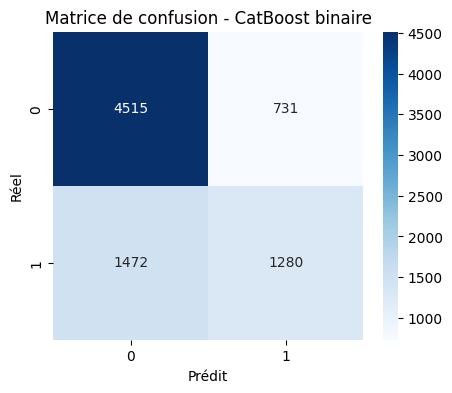

In [41]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cat_model_bin = CatBoostClassifier(
    iterations=800,
    depth=10,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_state=42,
    verbose=100
)

cat_model_bin.fit(
    X_train_bin,
    y_train_bin,
    eval_set=(X_test_bin, y_test_bin),
    use_best_model=True
)

y_pred_bin = cat_model_bin.predict(X_test_bin).flatten().astype(int)

print("Accuracy CatBoost binaire :", round(accuracy_score(y_test_bin, y_pred_bin), 4))
print("\nClassification report :\n")
print(classification_report(y_test_bin, y_pred_bin))

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
print("\nConfusion matrix :")
print(cm_bin)

plt.figure(figsize=(5,4))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - CatBoost binaire")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

4. modèle 2 : Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_bin = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_bin.fit(X_train_bin, y_train_bin)
y_pred_log_bin = log_bin.predict(X_test_bin)

print("--- Logistic Regression Binaire ---")
print("Accuracy :", round(accuracy_score(y_test_bin, y_pred_log_bin), 4))
print(classification_report(y_test_bin, y_pred_log_bin))
print(confusion_matrix(y_test_bin, y_pred_log_bin))

--- Logistic Regression Binaire ---
Accuracy : 0.689
              precision    recall  f1-score   support

           0       0.75      0.78      0.77      5246
           1       0.55      0.51      0.53      2752

    accuracy                           0.69      7998
   macro avg       0.65      0.65      0.65      7998
weighted avg       0.68      0.69      0.69      7998

[[4106 1140]
 [1347 1405]]


5. modele 3 : random forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_bin = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_bin.fit(X_train_bin, y_train_bin)
y_pred_rf_bin = rf_bin.predict(X_test_bin)

print("--- Random Forest Binaire ---")
print("Accuracy :", round(accuracy_score(y_test_bin, y_pred_rf_bin), 4))
print(classification_report(y_test_bin, y_pred_rf_bin))
print(confusion_matrix(y_test_bin, y_pred_rf_bin))

--- Random Forest Binaire ---
Accuracy : 0.6774
              precision    recall  f1-score   support

           0       0.83      0.64      0.72      5246
           1       0.52      0.74      0.61      2752

    accuracy                           0.68      7998
   macro avg       0.67      0.69      0.67      7998
weighted avg       0.72      0.68      0.69      7998

[[3368 1878]
 [ 702 2050]]


6. modèle 4 : XGBoost

In [44]:
from xgboost import XGBClassifier

xgb_bin = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_bin.fit(X_train_bin, y_train_bin)
y_pred_xgb_bin = xgb_bin.predict(X_test_bin)

print("--- XGBoost Binaire ---")
print("Accuracy :", round(accuracy_score(y_test_bin, y_pred_xgb_bin), 4))
print(classification_report(y_test_bin, y_pred_xgb_bin))
print(confusion_matrix(y_test_bin, y_pred_xgb_bin))

--- XGBoost Binaire ---
Accuracy : 0.7091
              precision    recall  f1-score   support

           0       0.75      0.84      0.79      5246
           1       0.60      0.46      0.52      2752

    accuracy                           0.71      7998
   macro avg       0.67      0.65      0.66      7998
weighted avg       0.70      0.71      0.70      7998

[[4399  847]
 [1480 1272]]


7. modèle 5 : LightGBM

In [45]:
from lightgbm import LGBMClassifier

lgbm_bin = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

lgbm_bin.fit(X_train_bin, y_train_bin)
y_pred_lgbm_bin = lgbm_bin.predict(X_test_bin)

print("--- LightGBM Binaire ---")
print("Accuracy :", round(accuracy_score(y_test_bin, y_pred_lgbm_bin), 4))
print(classification_report(y_test_bin, y_pred_lgbm_bin))
print(confusion_matrix(y_test_bin, y_pred_lgbm_bin))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 10515, number of negative: 21477
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3128
[LightGBM] [Info] Number of data points in the train set: 31992, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.328676 -> initscore=-0.714180
[LightGBM] [Info] Start training from score -0.714180
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

8. modèle 6 : MLPClassifier

In [46]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

scaler_mlp = StandardScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train_bin)
X_test_mlp = scaler_mlp.transform(X_test_bin)

mlp_bin = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=42
)

mlp_bin.fit(X_train_mlp, y_train_bin)
y_pred_mlp_bin = mlp_bin.predict(X_test_mlp)

print("--- MLP Classifier Binaire ---")
print("Accuracy :", round(accuracy_score(y_test_bin, y_pred_mlp_bin), 4))
print(classification_report(y_test_bin, y_pred_mlp_bin))
print(confusion_matrix(y_test_bin, y_pred_mlp_bin))

--- MLP Classifier Binaire ---
Accuracy : 0.6503
              precision    recall  f1-score   support

           0       0.74      0.73      0.73      5246
           1       0.49      0.50      0.50      2752

    accuracy                           0.65      7998
   macro avg       0.61      0.62      0.61      7998
weighted avg       0.65      0.65      0.65      7998

[[3818 1428]
 [1369 1383]]


9. comparaison !

In [47]:
comparison_binary = pd.DataFrame({
    "Modele": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "MLPClassifier"
    ],
    "Accuracy": [
        accuracy_score(y_test_bin, y_pred_log_bin),
        accuracy_score(y_test_bin, y_pred_rf_bin),
        accuracy_score(y_test_bin, y_pred_xgb_bin),
        accuracy_score(y_test_bin, y_pred_lgbm_bin),
        accuracy_score(y_test_bin, y_pred_bin),
        accuracy_score(y_test_bin, y_pred_mlp_bin)
    ]
})

display(comparison_binary.sort_values("Accuracy", ascending=False))

,Modele,Accuracy
4,CatBoost,0.724556
3,LightGBM,0.719055
2,XGBoost,0.709052
0,Logistic Regression,0.689047
1,Random Forest,0.677419
5,MLPClassifier,0.650288


10. sauvegarde de meilleur modèle :

In [48]:
cat_model_bin.save_model(f"{base_path}/catboost_sales_binary_model.cbm")
print("Modèle sauvegardé dans Google Drive.")

Modèle sauvegardé dans Google Drive.


# classification multiclasse

1. créer la cible de classification à partir de target_sales_qte

In [49]:
q1 = model_obj3["target_sales_qte"].quantile(0.33)
q2 = model_obj3["target_sales_qte"].quantile(0.66)

print("Seuil 1 :", q1)
print("Seuil 2 :", q2)

def classify_sales_level(x):
    if x <= q1:
        return 0   # faible
    elif x <= q2:
        return 1   # moyenne
    else:
        return 2   # élevée

model_obj3["sales_level_class"] = model_obj3["target_sales_qte"].apply(classify_sales_level)

print(model_obj3["sales_level_class"].value_counts())
model_obj3[["target_sales_qte", "sales_level_class"]].head(10)

Seuil 1 : 12.0
Seuil 2 : 52.0
sales_level_class
0    13900
2    13579
1    12511
Name: count, dtype: int64


,target_sales_qte,sales_level_class
56,66.0,2
57,264.0,2
58,147.0,2
59,24.0,1
60,22.0,1
61,6.0,0
62,24.0,1
63,276.0,2
64,60.0,2
65,176.0,2


2. 1er modele : Random Forest Classifier


In [50]:
excluded_cols_class = ["date", "article", "target_sales_qte", "sales_level_class"]

feature_cols_class = [col for col in model_obj3.columns if col not in excluded_cols_class]

X_class = model_obj3[feature_cols_class]
y_class = model_obj3["sales_level_class"]

print("Nombre de variables explicatives :", len(feature_cols_class))
print("Features :", feature_cols_class)
print("X shape :", X_class.shape)
print("y shape :", y_class.shape)

Nombre de variables explicatives : 27
Features : ['sales_qte', 'sales_grat', 'sales_ttc', 'sales_tht', 'movement_in_qte', 'movement_out_qte', 'zone_value', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'fam_Grossistes', 'fam_Para Pharmacie', 'fam_Pharmacies', 'zone_ZONE 3  ', 'zone_ZONE 5  ', 'zone_ZONE 6  ', 'zone_ZONE 7  ']
X shape : (39990, 27)
y shape : (39990,)


In [51]:
model_obj3_class = model_obj3.sort_values("date").reset_index(drop=True)

split_index = int(len(model_obj3_class) * 0.8)

train_class = model_obj3_class.iloc[:split_index].copy()
test_class = model_obj3_class.iloc[split_index:].copy()

X_train_class = train_class[feature_cols_class]
y_train_class = train_class["sales_level_class"]

X_test_class = test_class[feature_cols_class]
y_test_class = test_class["sales_level_class"]

print("Train shape :", X_train_class.shape)
print("Test shape  :", X_test_class.shape)
print("Train period :", train_class["date"].min(), "->", train_class["date"].max())
print("Test period  :", test_class["date"].min(), "->", test_class["date"].max())
print("\nRépartition train :")
print(y_train_class.value_counts())
print("\nRépartition test :")
print(y_test_class.value_counts())

Train shape : (31992, 27)
Test shape  : (7998, 27)
Train period : 2022-02-09 00:00:00 -> 2023-05-31 00:00:00
Test period  : 2023-05-31 00:00:00 -> 2023-10-10 00:00:00

Répartition train :
sales_level_class
0    11275
2    10760
1     9957
Name: count, dtype: int64

Répartition test :
sales_level_class
2    2819
0    2625
1    2554
Name: count, dtype: int64


In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_class, y_train_class)

y_pred_class = rf_clf.predict(X_test_class)

print("--- Random Forest Classifier ---")
print("Accuracy :", round(accuracy_score(y_test_class, y_pred_class), 4))
print("\nClassification report :")
print(classification_report(y_test_class, y_pred_class))
print("\nConfusion matrix :")
print(confusion_matrix(y_test_class, y_pred_class))

--- Random Forest Classifier ---
Accuracy : 0.493

Classification report :
              precision    recall  f1-score   support

           0       0.53      0.49      0.51      2625
           1       0.38      0.26      0.31      2554
           2       0.52      0.71      0.60      2819

    accuracy                           0.49      7998
   macro avg       0.48      0.49      0.47      7998
weighted avg       0.48      0.49      0.48      7998


Confusion matrix :
[[1283  585  757]
 [ 828  666 1060]
 [ 322  503 1994]]


3. 2eme modele: Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_clf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_clf.fit(X_train_class, y_train_class)

y_pred_log = log_clf.predict(X_test_class)

print("--- Logistic Regression ---")
print("Accuracy :", round(accuracy_score(y_test_class, y_pred_log), 4))
print("\nClassification report :")
print(classification_report(y_test_class, y_pred_log))
print("\nConfusion matrix :")
print(confusion_matrix(y_test_class, y_pred_log))

--- Logistic Regression ---
Accuracy : 0.4624

Classification report :
              precision    recall  f1-score   support

           0       0.42      0.75      0.54      2625
           1       0.34      0.10      0.16      2554
           2       0.58      0.52      0.55      2819

    accuracy                           0.46      7998
   macro avg       0.45      0.46      0.41      7998
weighted avg       0.45      0.46      0.42      7998


Confusion matrix :
[[1962  225  438]
 [1663  261  630]
 [1066  278 1475]]


4. 3eme modele : Gradient Boosting Classifier

In [54]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train_class, y_train_class)

y_pred_gb = gb_clf.predict(X_test_class)

print("--- Gradient Boosting Classifier ---")
print("Accuracy :", round(accuracy_score(y_test_class, y_pred_gb), 4))
print("\nClassification report :")
print(classification_report(y_test_class, y_pred_gb))
print("\nConfusion matrix :")
print(confusion_matrix(y_test_class, y_pred_gb))

--- Gradient Boosting Classifier ---
Accuracy : 0.5041

Classification report :
              precision    recall  f1-score   support

           0       0.54      0.52      0.53      2625
           1       0.38      0.24      0.30      2554
           2       0.53      0.73      0.62      2819

    accuracy                           0.50      7998
   macro avg       0.48      0.50      0.48      7998
weighted avg       0.49      0.50      0.49      7998


Confusion matrix :
[[1353  541  731]
 [ 862  624 1068]
 [ 282  482 2055]]


5. 4eme modele : XGBoost Classifier

In [55]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)

xgb_clf.fit(X_train_class, y_train_class)
y_pred_xgb = xgb_clf.predict(X_test_class)

print("--- XGBoost Classifier ---")
print("Accuracy :", round(accuracy_score(y_test_class, y_pred_xgb), 4))
print(classification_report(y_test_class, y_pred_xgb))
print(confusion_matrix(y_test_class, y_pred_xgb))

--- XGBoost Classifier ---
Accuracy : 0.5004
              precision    recall  f1-score   support

           0       0.54      0.50      0.52      2625
           1       0.38      0.27      0.31      2554
           2       0.53      0.71      0.61      2819

    accuracy                           0.50      7998
   macro avg       0.48      0.49      0.48      7998
weighted avg       0.49      0.50      0.49      7998

[[1325  587  713]
 [ 840  679 1035]
 [ 280  541 1998]]


6. 5eme modele : LightGBM Classifier

In [56]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lgbm_clf = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgbm_clf.fit(X_train_class, y_train_class)
y_pred_lgbm = lgbm_clf.predict(X_test_class)

print("--- LightGBM Classifier ---")
print("Accuracy :", round(accuracy_score(y_test_class, y_pred_lgbm), 4))
print(classification_report(y_test_class, y_pred_lgbm))
print(confusion_matrix(y_test_class, y_pred_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3128
[LightGBM] [Info] Number of data points in the train set: 31992, number of used features: 26
[LightGBM] [Info] Start training from score -1.042898
[LightGBM] [Info] Start training from score -1.167210
[LightGBM] [Info] Start training from score -1.089650
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

7. 6eme modele : CatBoost Classifier

In [57]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

cat_clf = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    verbose=0,
    random_state=42
)

cat_clf.fit(X_train_class, y_train_class)
y_pred_cat = cat_clf.predict(X_test_class)
y_pred_cat = y_pred_cat.flatten().astype(int)

print("--- CatBoost Classifier ---")
print("Accuracy :", round(accuracy_score(y_test_class, y_pred_cat), 4))
print(classification_report(y_test_class, y_pred_cat))
print(confusion_matrix(y_test_class, y_pred_cat))

--- CatBoost Classifier ---
Accuracy : 0.5046
              precision    recall  f1-score   support

           0       0.55      0.50      0.53      2625
           1       0.38      0.27      0.32      2554
           2       0.54      0.72      0.61      2819

    accuracy                           0.50      7998
   macro avg       0.49      0.50      0.49      7998
weighted avg       0.49      0.50      0.49      7998

[[1316  599  710]
 [ 817  701 1036]
 [ 255  545 2019]]


8. comparaison !

In [58]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_class = {
    "Logistic Regression": log_clf,
    "Random Forest": rf_clf,
    "Gradient Boosting": gb_clf,
    "XGBoost": xgb_clf,
    "LightGBM": lgbm_clf,
    "CatBoost": cat_clf
}

results_class = []

for name, model in models_class.items():
    y_pred = model.predict(X_test_class)
    y_pred = np.array(y_pred).reshape(-1)

    results_class.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_class, y_pred),
        "Precision": precision_score(y_test_class, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test_class, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test_class, y_pred, average="weighted", zero_division=0)
    })

results_class = pd.DataFrame(results_class).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_class

,Model,Accuracy,Precision,Recall,F1-score
0,CatBoost,0.504626,0.491209,0.504626,0.490261
1,LightGBM,0.504251,0.490325,0.504251,0.491043
2,Gradient Boosting,0.504126,0.486761,0.504126,0.485346
3,XGBoost,0.500375,0.485847,0.500375,0.485524
4,Random Forest,0.492998,0.478741,0.492998,0.477248
5,Logistic Regression,0.462366,0.450799,0.462366,0.420189


## partie 2 : Prédire la tendance des ventes

la prochaine vente va-t-elle augmenter ou diminuer par rapport à l’actuelle ?

1. créer la variable cible de tendance

In [59]:
model_obj3["sales_trend"] = (model_obj3["target_sales_qte"] > model_obj3["sales_qte"]).astype(int)

print(model_obj3["sales_trend"].value_counts())
model_obj3[["sales_qte", "target_sales_qte", "sales_trend"]].head(10)

sales_trend
0    21078
1    18912
Name: count, dtype: int64


,sales_qte,target_sales_qte,sales_trend
56,28,66.0,1
57,66,264.0,1
58,264,147.0,0
59,147,24.0,0
60,24,22.0,0
61,22,6.0,0
62,6,24.0,1
63,24,276.0,1
64,276,60.0,0
65,60,176.0,1


In [60]:
excluded_cols_trend = [
    "date",
    "article",
    "target_sales_qte",
    "sales_level_class",
    "sales_trend"
]

feature_cols_trend = [col for col in model_obj3.columns if col not in excluded_cols_trend]

X_trend = model_obj3[feature_cols_trend]
y_trend = model_obj3["sales_trend"]

print("Nombre de features :", len(feature_cols_trend))
print("Features :", feature_cols_trend)
print("X shape :", X_trend.shape)
print("y shape :", y_trend.shape)

Nombre de features : 27
Features : ['sales_qte', 'sales_grat', 'sales_ttc', 'sales_tht', 'movement_in_qte', 'movement_out_qte', 'zone_value', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'fam_Grossistes', 'fam_Para Pharmacie', 'fam_Pharmacies', 'zone_ZONE 3  ', 'zone_ZONE 5  ', 'zone_ZONE 6  ', 'zone_ZONE 7  ']
X shape : (39990, 27)
y shape : (39990,)


In [61]:
model_trend = model_obj3.sort_values("date").reset_index(drop=True)

split_index = int(len(model_trend) * 0.8)

train_trend = model_trend.iloc[:split_index].copy()
test_trend = model_trend.iloc[split_index:].copy()

X_train_trend = train_trend[feature_cols_trend]
y_train_trend = train_trend["sales_trend"]

X_test_trend = test_trend[feature_cols_trend]
y_test_trend = test_trend["sales_trend"]

print("Train shape :", X_train_trend.shape)
print("Test shape  :", X_test_trend.shape)
print("Train period :", train_trend["date"].min(), "->", train_trend["date"].max())
print("Test period  :", test_trend["date"].min(), "->", test_trend["date"].max())

print("\nRépartition train :")
print(y_train_trend.value_counts())

print("\nRépartition test :")
print(y_test_trend.value_counts())

Train shape : (31992, 27)
Test shape  : (7998, 27)
Train period : 2022-02-09 00:00:00 -> 2023-05-31 00:00:00
Test period  : 2023-05-31 00:00:00 -> 2023-10-10 00:00:00

Répartition train :
sales_trend
0    16824
1    15168
Name: count, dtype: int64

Répartition test :
sales_trend
0    4254
1    3744
Name: count, dtype: int64


2. 1er modele : Logestic regression

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_trend = LogisticRegression(max_iter=1000, random_state=42)
log_trend.fit(X_train_trend, y_train_trend)

y_pred_log_trend = log_trend.predict(X_test_trend)

print("--- Logistic Regression (trend) ---")
print("Accuracy :", round(accuracy_score(y_test_trend, y_pred_log_trend), 4))
print("\nClassification report :")
print(classification_report(y_test_trend, y_pred_log_trend))
print("\nConfusion matrix :")
print(confusion_matrix(y_test_trend, y_pred_log_trend))

--- Logistic Regression (trend) ---
Accuracy : 0.6405

Classification report :
              precision    recall  f1-score   support

           0       0.63      0.78      0.70      4254
           1       0.66      0.48      0.55      3744

    accuracy                           0.64      7998
   macro avg       0.65      0.63      0.63      7998
weighted avg       0.64      0.64      0.63      7998


Confusion matrix :
[[3331  923]
 [1952 1792]]


3. 2eme modele : random forest classifier

In [63]:
from sklearn.ensemble import RandomForestClassifier

rf_trend = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_trend.fit(X_train_trend, y_train_trend)

y_pred_rf_trend = rf_trend.predict(X_test_trend)

print("--- Random Forest (trend) ---")
print("Accuracy :", round(accuracy_score(y_test_trend, y_pred_rf_trend), 4))
print("\nClassification report :")
print(classification_report(y_test_trend, y_pred_rf_trend))
print("\nConfusion matrix :")
print(confusion_matrix(y_test_trend, y_pred_rf_trend))

--- Random Forest (trend) ---
Accuracy : 0.7189

Classification report :
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      4254
           1       0.69      0.72      0.70      3744

    accuracy                           0.72      7998
   macro avg       0.72      0.72      0.72      7998
weighted avg       0.72      0.72      0.72      7998


Confusion matrix :
[[3073 1181]
 [1067 2677]]


4. 3eme modele : gradient boosting classifier

In [64]:
from sklearn.ensemble import GradientBoostingClassifier

gb_trend = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_trend.fit(X_train_trend, y_train_trend)

y_pred_gb_trend = gb_trend.predict(X_test_trend)

print("--- Gradient Boosting (trend) ---")
print("Accuracy :", round(accuracy_score(y_test_trend, y_pred_gb_trend), 4))
print("\nClassification report :")
print(classification_report(y_test_trend, y_pred_gb_trend))
print("\nConfusion matrix :")
print(confusion_matrix(y_test_trend, y_pred_gb_trend))

--- Gradient Boosting (trend) ---
Accuracy : 0.7188

Classification report :
              precision    recall  f1-score   support

           0       0.74      0.73      0.73      4254
           1       0.70      0.71      0.70      3744

    accuracy                           0.72      7998
   macro avg       0.72      0.72      0.72      7998
weighted avg       0.72      0.72      0.72      7998


Confusion matrix :
[[3086 1168]
 [1081 2663]]


5. comparaison !

In [65]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Regrouper les modèles déjà entraînés
models_trend = {
    "Logistic Regression": log_trend,
    "Random Forest": rf_trend,
    "Gradient Boosting": gb_trend
}

results_trend = []

for name, model in models_trend.items():
    # prédictions automatiques
    y_pred = model.predict(X_test_trend)

    # calcul automatique des scores
    results_trend.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_trend, y_pred),
        "Precision": precision_score(y_test_trend, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test_trend, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test_trend, y_pred, average="weighted", zero_division=0)
    })

# tableau final
results_trend = pd.DataFrame(results_trend)

# trier par accuracy décroissante
results_trend = results_trend.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

results_trend

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.718930,0.719619,0.718930,0.719129
1,Gradient Boosting,0.718805,0.719299,0.718805,0.718967
2,Logistic Regression,0.640535,0.644334,0.640535,0.631294


6. sauvegarde du meilleur modèle

In [127]:
import joblib

joblib.dump(rf_trend, f"{base_path}/rf_trend_model.pkl")

print("Modèle Random Forest (trend) sauvegardé dans Google Drive.")

Modèle Random Forest (trend) sauvegardé dans Google Drive.


# DSO 3 — Partie 3 : Segmentation des articles selon leur comportement de vente






Dans cette partie, l’objectif est de segmenter les articles selon leur comportement de vente à partir des ventes journalières.
Contrairement aux parties précédentes, cette analyse adopte une approche non supervisée.
Elle permet d’identifier des groupes d’articles ayant des profils similaires, comme des articles très performants, stables ou peu demandés.

In [66]:
print(sales_article_day.head())
print(sales_article_day.shape)
print(sales_article_day.columns)

  article       date  sales_qte  sales_grat  sales_ttc  sales_tht         fam
0   ANNUL 2022-01-07          1           0        0.0        0.0  Grossistes
1   ANNUL 2022-01-18          1           0        0.0        0.0  Pharmacies
2   ANNUL 2022-01-25          1           0        0.0        0.0  Pharmacies
3   ANNUL 2022-02-28          1           0        0.0        0.0  Grossistes
4   ANNUL 2022-03-11          1           0        0.0        0.0  Pharmacies
(51660, 7)
Index(['article', 'date', 'sales_qte', 'sales_grat', 'sales_ttc', 'sales_tht',
       'fam'],
      dtype='object')


2. transforme ta table journalière en une table résumée par article.

In [67]:
article_features = sales_article_day.groupby('article').agg(
    total_sales=('sales_qte', 'sum'),
    mean_sales=('sales_qte', 'mean'),
    std_sales=('sales_qte', 'std'),
    max_sales=('sales_qte', 'max'),
    min_sales=('sales_qte', 'min'),
    total_ttc=('sales_ttc', 'sum'),
    total_tht=('sales_tht', 'sum'),
    days_observed=('date', 'nunique'),
    active_days=('sales_qte', lambda x: (x > 0).sum())
).reset_index()

article_features['sales_frequency'] = article_features['active_days'] / article_features['days_observed']
article_features['std_sales'] = article_features['std_sales'].fillna(0)

article_features.head()

,article,total_sales,mean_sales,std_sales,max_sales,min_sales,total_ttc,total_tht,days_observed,active_days,sales_frequency
0,ANNUL,25,1.000000,0.000000,1,1,0.000,0.000,25,25,1.0
1,C3.29,640,640.000000,0.000000,640,640,22848.000,19200.000,1,1,1.0
2,CANDEREL004,16956,70.945607,93.340442,640,2,182839.644,153646.737,239,239,1.0
3,CANDEREL005,5338,44.857143,59.868540,440,1,68915.946,57912.564,119,119,1.0
4,CANDEREL006,2464,24.640000,30.076844,228,1,31152.879,26178.890,100,100,1.0


3. retirer sales_frequency du clustering

In [68]:
from sklearn.preprocessing import StandardScaler

clustering_data = article_features[
    ['total_sales', 'mean_sales', 'std_sales', 'max_sales', 'total_ttc', 'total_tht']
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_data)

print(clustering_data.head())
print(X_scaled.shape)

   total_sales  mean_sales  std_sales  max_sales   total_ttc   total_tht
0           25    1.000000   0.000000          1       0.000       0.000
1          640  640.000000   0.000000        640   22848.000   19200.000
2        16956   70.945607  93.340442        640  182839.644  153646.737
3         5338   44.857143  59.868540        440   68915.946   57912.564
4         2464   24.640000  30.076844        228   31152.879   26178.890
(457, 6)


4. tester plusieurs nombres de clusters

In [69]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

5. méthoode de coude

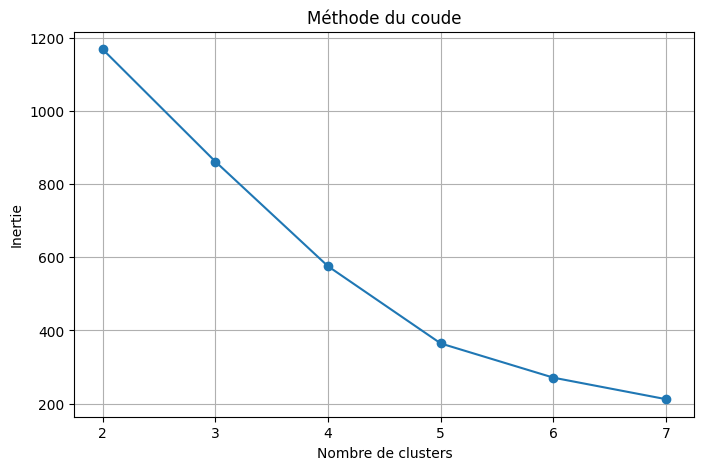

In [70]:
plt.figure(figsize=(8,5))
plt.plot(list(K_range), inertias, marker='o')
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.grid(True)
plt.show()

6. silouhette score

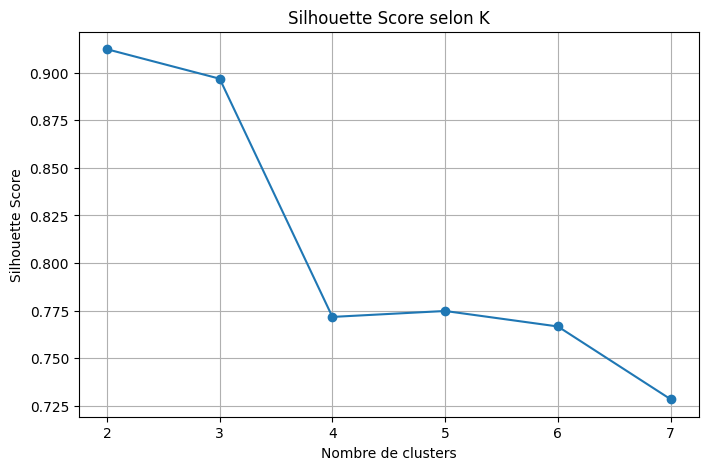

In [71]:
plt.figure(figsize=(8,5))
plt.plot(list(K_range), silhouette_scores, marker='o')
plt.title("Silhouette Score selon K")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

7. tester KMeans avec k=3

In [72]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
article_features['cluster_3'] = kmeans_3.fit_predict(X_scaled)

cluster_summary_3 = article_features.groupby('cluster_3').agg(
    nb_articles=('article', 'count'),
    total_sales_mean=('total_sales', 'mean'),
    mean_sales_mean=('mean_sales', 'mean'),
    std_sales_mean=('std_sales', 'mean'),
    max_sales_mean=('max_sales', 'mean'),
    total_ttc_mean=('total_ttc', 'mean'),
    total_tht_mean=('total_tht', 'mean')
).reset_index()

print("Résumé des clusters pour k=3")
display(cluster_summary_3)

Résumé des clusters pour k=3


,cluster_3,nb_articles,total_sales_mean,mean_sales_mean,std_sales_mean,max_sales_mean,total_ttc_mean,total_tht_mean
0,0,444,7845.486486,43.613927,64.792667,477.659910,8.331692e+04,6.987708e+04
1,1,12,185250.666667,756.733153,1418.143278,11612.416667,1.525013e+06,1.280579e+06
2,2,1,597328.000000,1627.596730,4133.218056,54989.000000,1.979882e+06,1.663767e+06


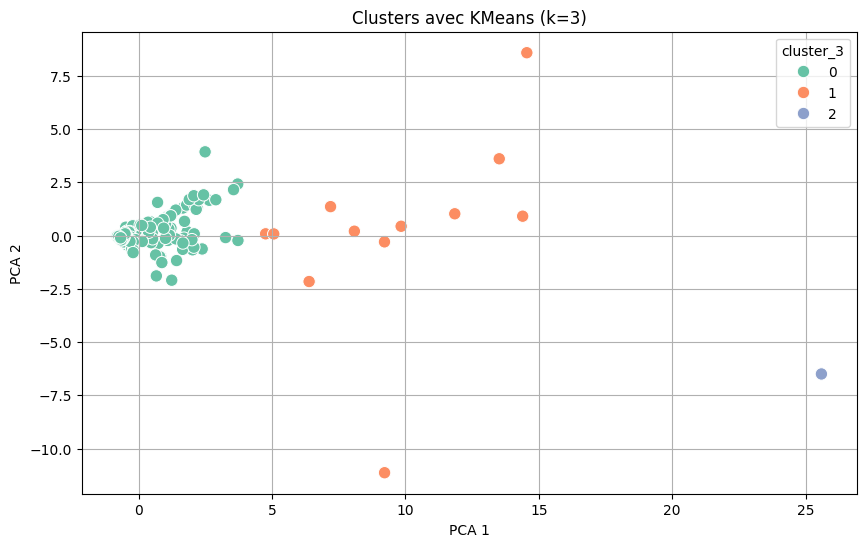

In [73]:
#visualisation PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

article_features['pca1'] = X_pca[:, 0]
article_features['pca2'] = X_pca[:, 1]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=article_features,
    x='pca1',
    y='pca2',
    hue='cluster_3',
    palette='Set2',
    s=80
)
plt.title("Clusters avec KMeans (k=3)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

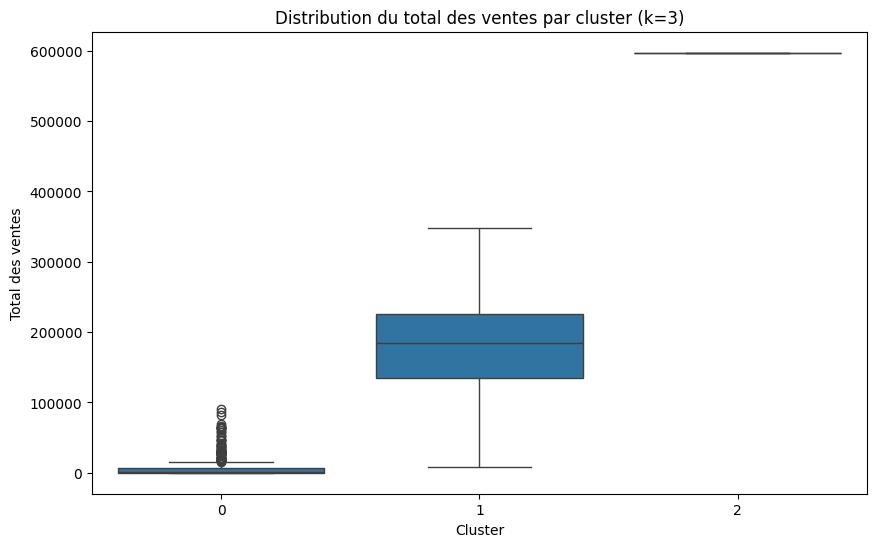

In [74]:
#boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=article_features, x='cluster_3', y='total_sales')
plt.title("Distribution du total des ventes par cluster (k=3)")
plt.xlabel("Cluster")
plt.ylabel("Total des ventes")
plt.show()

8. tester KMeans avec k=5

In [75]:
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
article_features['cluster_5'] = kmeans_5.fit_predict(X_scaled)

cluster_summary_5 = article_features.groupby('cluster_5').agg(
    nb_articles=('article', 'count'),
    total_sales_mean=('total_sales', 'mean'),
    mean_sales_mean=('mean_sales', 'mean'),
    std_sales_mean=('std_sales', 'mean'),
    max_sales_mean=('max_sales', 'mean'),
    total_ttc_mean=('total_ttc', 'mean'),
    total_tht_mean=('total_tht', 'mean')
).reset_index()

print("Résumé des clusters pour k=5")
display(cluster_summary_5)

Résumé des clusters pour k=5


,cluster_5,nb_articles,total_sales_mean,mean_sales_mean,std_sales_mean,max_sales_mean,total_ttc_mean,total_tht_mean
0,0,399,3787.278195,30.926530,39.190379,262.716792,3.544241e+04,2.966532e+04
1,1,8,228031.625000,665.587710,1428.224186,12900.250000,2.030396e+06,1.704798e+06
2,2,48,49234.520833,170.645713,331.864235,2866.437500,5.188896e+05,4.357559e+05
3,3,1,597328.000000,1627.596730,4133.218056,54989.000000,1.979882e+06,1.663767e+06
4,4,1,7770.000000,2590.000000,2793.425317,5815.000000,1.479408e+03,1.243200e+03


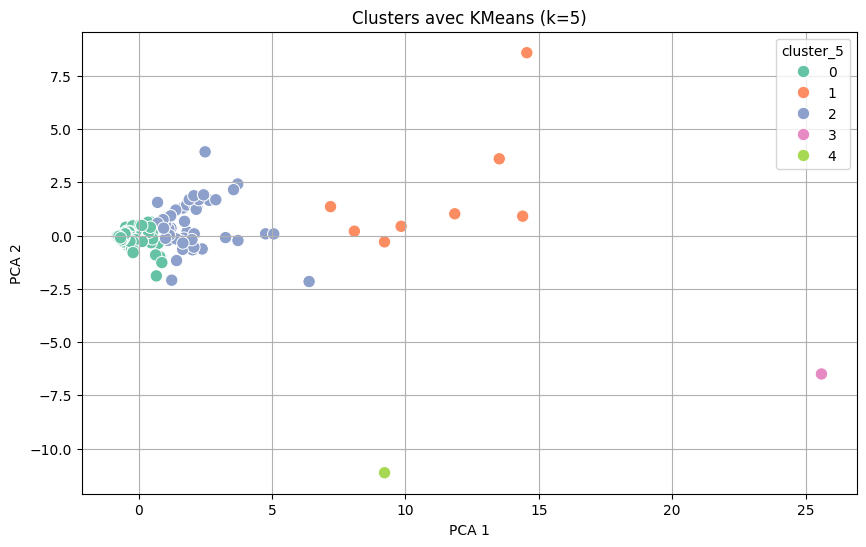

In [76]:
#visualisation PCA
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=article_features,
    x='pca1',
    y='pca2',
    hue='cluster_5',
    palette='Set2',
    s=80
)
plt.title("Clusters avec KMeans (k=5)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

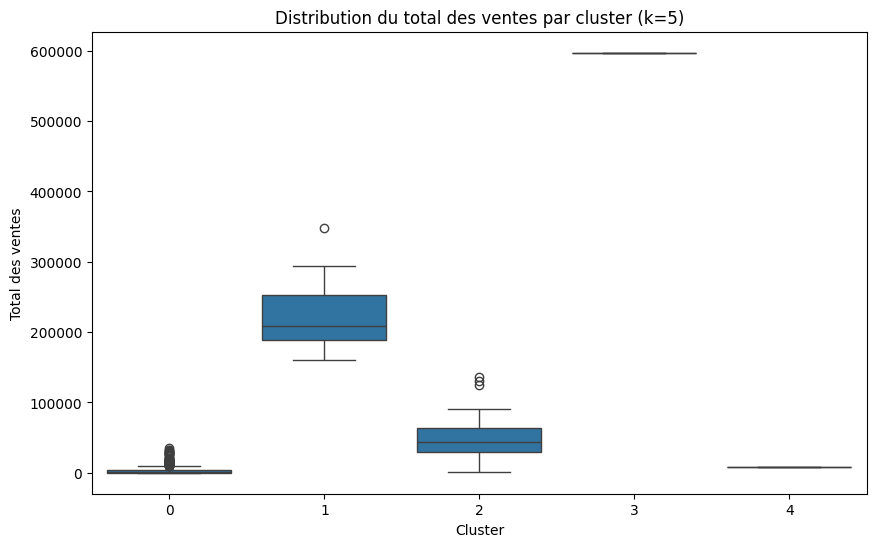

In [77]:
#boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=article_features, x='cluster_5', y='total_sales')
plt.title("Distribution du total des ventes par cluster (k=5)")
plt.xlabel("Cluster")
plt.ylabel("Total des ventes")
plt.show()

9. tester KMeans avec k=4

In [78]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
article_features['cluster_4'] = kmeans_4.fit_predict(X_scaled)

cluster_summary_4 = article_features.groupby('cluster_4').agg(
    nb_articles=('article', 'count'),
    total_sales_mean=('total_sales', 'mean'),
    mean_sales_mean=('mean_sales', 'mean'),
    std_sales_mean=('std_sales', 'mean'),
    max_sales_mean=('max_sales', 'mean'),
    total_ttc_mean=('total_ttc', 'mean'),
    total_tht_mean=('total_tht', 'mean')
).reset_index()

print("Résumé des clusters pour k=4")
display(cluster_summary_5)

Résumé des clusters pour k=4


,cluster_5,nb_articles,total_sales_mean,mean_sales_mean,std_sales_mean,max_sales_mean,total_ttc_mean,total_tht_mean
0,0,399,3787.278195,30.926530,39.190379,262.716792,3.544241e+04,2.966532e+04
1,1,8,228031.625000,665.587710,1428.224186,12900.250000,2.030396e+06,1.704798e+06
2,2,48,49234.520833,170.645713,331.864235,2866.437500,5.188896e+05,4.357559e+05
3,3,1,597328.000000,1627.596730,4133.218056,54989.000000,1.979882e+06,1.663767e+06
4,4,1,7770.000000,2590.000000,2793.425317,5815.000000,1.479408e+03,1.243200e+03


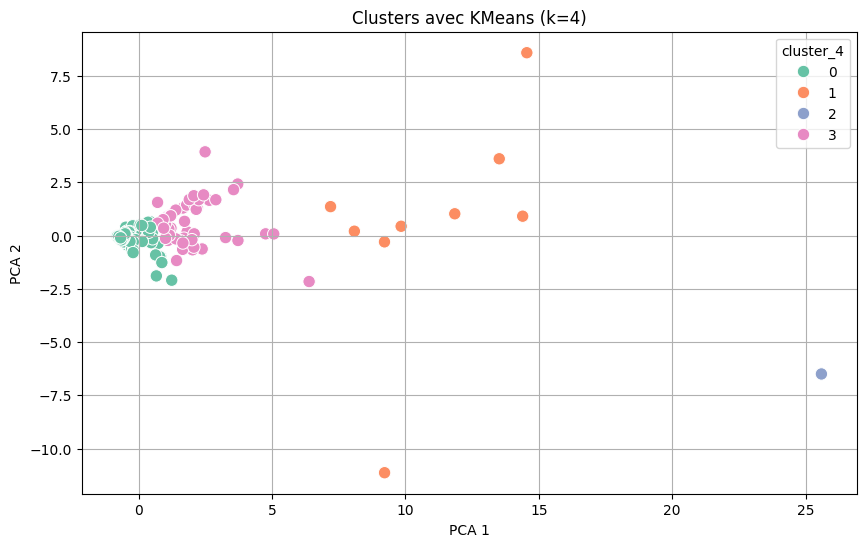

In [79]:
#visualisation PCA
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=article_features,
    x='pca1',
    y='pca2',
    hue='cluster_4',
    palette='Set2',
    s=80
)
plt.title("Clusters avec KMeans (k=4)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

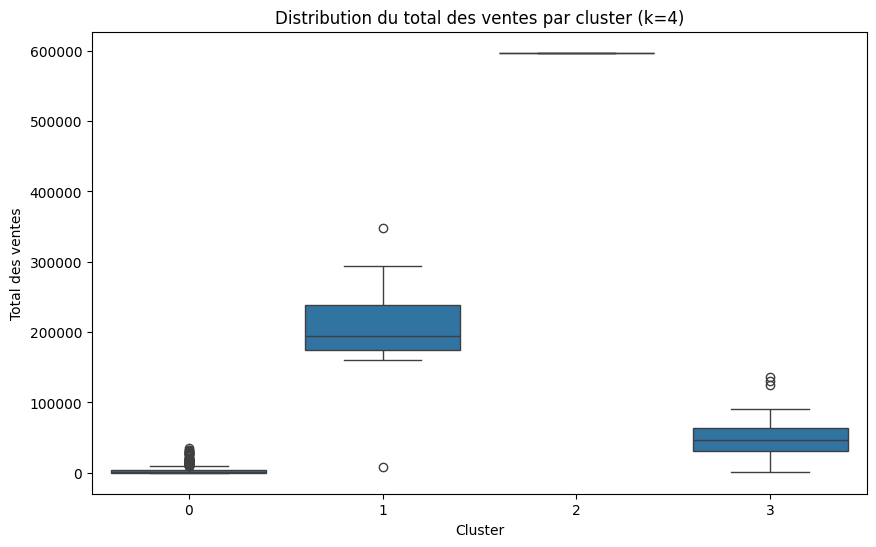

In [80]:
#boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=article_features, x='cluster_4', y='total_sales')
plt.title("Distribution du total des ventes par cluster (k=4)")
plt.xlabel("Cluster")
plt.ylabel("Total des ventes")
plt.show()

10. tester KMeans avec k=2

In [81]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
article_features['cluster_2'] = kmeans_2.fit_predict(X_scaled)

cluster_summary_2 = article_features.groupby('cluster_2').agg(
    nb_articles=('article', 'count'),
    total_sales_mean=('total_sales', 'mean'),
    mean_sales_mean=('mean_sales', 'mean'),
    std_sales_mean=('std_sales', 'mean'),
    max_sales_mean=('max_sales', 'mean'),
    total_ttc_mean=('total_ttc', 'mean'),
    total_tht_mean=('total_tht', 'mean')
).reset_index()

print("Résumé des clusters pour k=2")
display(cluster_summary_2)

Résumé des clusters pour k=2


,cluster_2,nb_articles,total_sales_mean,mean_sales_mean,std_sales_mean,max_sales_mean,total_ttc_mean,total_tht_mean
0,0,446,8382.883408,45.097315,67.968490,504.818386,8.646683e+04,7.252468e+04
1,1,11,233178.727273,905.415940,1782.266812,16479.090909,1.700777e+06,1.428194e+06


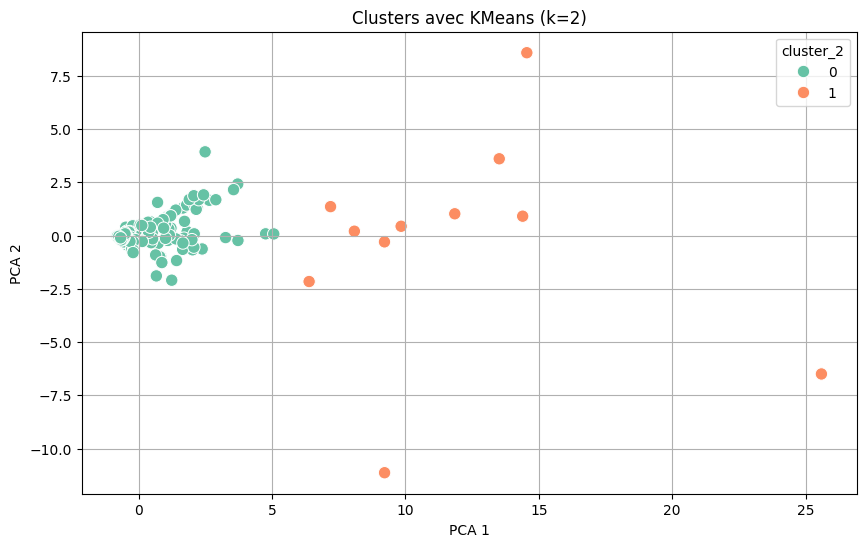

In [82]:
#visualisation PCA
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=article_features,
    x='pca1',
    y='pca2',
    hue='cluster_2',
    palette='Set2',
    s=80
)
plt.title("Clusters avec KMeans (k=2)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

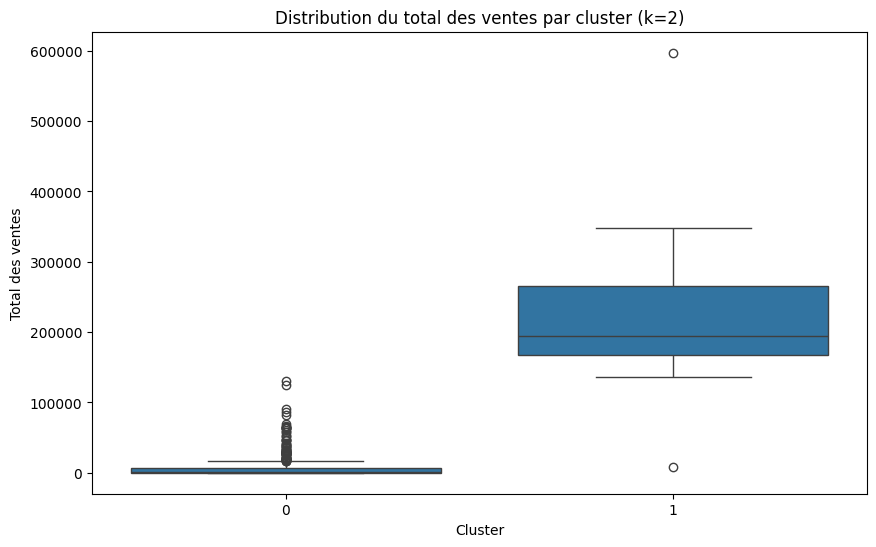

In [83]:
#boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=article_features, x='cluster_2', y='total_sales')
plt.title("Distribution du total des ventes par cluster (k=2)")
plt.xlabel("Cluster")
plt.ylabel("Total des ventes")
plt.show()

In [84]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

results = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    sil_score = silhouette_score(X_scaled, labels)

    results.append((k, inertia, sil_score))

results_df = pd.DataFrame(results, columns=["k", "inertia", "silhouette_score"])
display(results_df)

,k,inertia,silhouette_score
0,2,1168.550357,0.912257
1,3,861.702994,0.896775
2,4,575.417079,0.771754
3,5,364.478157,0.774870
4,6,270.952130,0.766738
5,7,212.105166,0.728556
6,8,170.859493,0.724597
7,9,144.815509,0.729104
8,10,125.760918,0.729784


In [85]:
best_row = results_df.loc[results_df["silhouette_score"].idxmax()]

best_k = int(best_row["k"])
best_sil = best_row["silhouette_score"]

print("Meilleur k :", best_k)
print("Meilleur silhouette :", round(best_sil, 4))

Meilleur k : 2
Meilleur silhouette : 0.9123


In [86]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
article_features["cluster_final"] = kmeans_final.fit_predict(X_scaled)

11. modèle 2 : DBSCan

In [87]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

article_features["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

# attention: DBSCAN peut donner -1 (bruit)
if len(set(article_features["cluster_dbscan"])) > 1:
    sil_db = silhouette_score(X_scaled, article_features["cluster_dbscan"])
    print("Silhouette DBSCAN :", round(sil_db, 4))
else:
    print("DBSCAN n'a pas trouvé plusieurs clusters")

Silhouette DBSCAN : 0.7045


12. modèle 3 : Gaussian Mixture Model (GMM)

In [88]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=42)

article_features["cluster_gmm"] = gmm.fit_predict(X_scaled)

sil_gmm = silhouette_score(X_scaled, article_features["cluster_gmm"])

print("Silhouette GMM :", round(sil_gmm, 4))

Silhouette GMM : 0.5366


13. comparaison !

In [89]:
comparison = pd.DataFrame({
    "Model": ["KMeans", "DBSCAN", "GMM"],
    "Silhouette_Score": [best_sil, sil_db, sil_gmm]
})

display(comparison.sort_values("Silhouette_Score", ascending=False))

,Model,Silhouette_Score
0,KMeans,0.912257
1,DBSCAN,0.704469
2,GMM,0.536611


Cluster 0 : articles à faible performance, caractérisés par un faible volume de ventes et une faible contribution au chiffre d’affaires.
Cluster 1 : articles à forte performance, représentant les produits les plus rentables et générant la majorité des ventes.

14. visualisation des clusters

In [90]:
for c in sorted(article_features['cluster_2'].unique()):
    print(f"\n===== Cluster {c} =====")
    display(
        article_features[article_features['cluster_2'] == c][
            ['article', 'total_sales', 'mean_sales', 'std_sales', 'max_sales', 'total_ttc', 'total_tht']
        ].sort_values(by='total_sales', ascending=False).head(10)
    )


===== Cluster 0 =====


,article,total_sales,mean_sales,std_sales,max_sales,total_ttc,total_tht
50,PF203,130364,380.069971,781.472018,7030,803028.377,674813.776
49,PF202,125006,368.749263,764.530447,6038,768466.257,645769.977
14,PF012,91127,274.478916,448.784329,3567,290353.502,243994.505
94,PF325,86905,282.159091,583.037333,4688,539719.678,453545.944
116,PF348,82263,287.632867,730.260445,6240,583562.110,490388.321
218,PF806,68713,188.771978,342.030431,2818,1140894.720,958734.960
214,PF801,65951,169.976804,296.125998,2457,861677.543,724098.757
23,PF028,65557,208.117460,411.790763,5200,234308.938,196898.241
158,PF521,65349,216.387417,408.972961,2841,350327.300,291477.915
77,PF308,63996,191.604790,331.033443,2332,270869.748,225368.006



===== Cluster 1 =====


,article,total_sales,mean_sales,std_sales,max_sales,total_ttc,total_tht
326,PFO01,597328,1627.596730,4133.218056,54989,1979882.485,1663766.727
81,PF312,347745,965.958333,1923.273954,16283,2208277.763,1855695.573
170,PF539,294084,757.948454,1593.210450,13408,1874764.649,1575432.427
82,PF313,238276,690.655072,1392.349102,11635,1517997.072,1275627.766
149,PF511,221588,560.982278,1169.093252,10617,3925425.942,3298677.272
83,PF314,194869,559.968391,1215.854220,10406,1233272.519,1036363.437
263,PFE01,193322,746.416988,1378.586596,12482,1349506.486,1134039.089
69,PF301,174636,468.193029,925.332579,7318,1362249.084,1133412.925
328,PFO03,159733,574.579137,1828.093331,21053,2771671.324,2329135.564
327,PFO02,135615,417.276923,1252.498071,17264,484017.769,406737.588


15. sauvegarde du meilleur modèle

In [157]:
import joblib

joblib.dump(kmeans_final, f"{base_path}/kmeans_articles_model.pkl")

print("Modèle KMeans sauvegardé dans Google Drive.")

Modèle KMeans sauvegardé dans Google Drive.


# Partie 4 — Prédiction du chiffre d’affaires

Dans cette partie, l’objectif est de prédire le chiffre d’affaires TTC (`sales_ttc`) à partir des variables commerciales, logistiques, temporelles et historiques disponibles dans `obj3_df`.

In [91]:
print(obj3_df.shape)
print(obj3_df.columns.tolist())
obj3_df.head()

(51660, 25)
['article', 'date', 'sales_qte', 'sales_grat', 'sales_ttc', 'sales_tht', 'fam', 'movement_in_qte', 'movement_out_qte', 'zone', 'zone_value', 'year', 'month', 'day', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend', 'target_sales_qte', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30']


,article,date,sales_qte,sales_grat,sales_ttc,sales_tht,fam,movement_in_qte,movement_out_qte,zone,...,quarter,week_of_year,is_weekend,target_sales_qte,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30
0,ANNUL,2022-01-07,1,0,0.0,0.0,Grossistes,0.0,0.0,Unknown,...,1,1,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,ANNUL,2022-01-18,1,0,0.0,0.0,Pharmacies,0.0,0.0,Unknown,...,1,3,0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
2,ANNUL,2022-01-25,1,0,0.0,0.0,Pharmacies,0.0,0.0,Unknown,...,1,4,0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
3,ANNUL,2022-02-28,1,0,0.0,0.0,Grossistes,0.0,0.0,Unknown,...,1,9,0,1.0,1.0,NaN,NaN,NaN,NaN,NaN
4,ANNUL,2022-03-11,1,0,0.0,0.0,Pharmacies,0.0,0.0,Unknown,...,1,10,0,1.0,1.0,NaN,NaN,NaN,NaN,NaN


In [92]:
reg_df = obj3_df.copy()

In [93]:
target_reg = "sales_ttc"

Expérience A : prédiction sans historique

In [94]:
features_reg_A = [
    "sales_qte",
    "fam",
    "movement_in_qte",
    "movement_out_qte",
    "zone",
    "zone_value",
    "year",
    "month",
    "day",
    "day_of_week",
    "quarter",
    "week_of_year",
    "is_weekend"
]

In [95]:
reg_data_A = reg_df[features_reg_A + [target_reg]].dropna().copy()

print("Shape de reg_data_A :", reg_data_A.shape)
reg_data_A.head()

Shape de reg_data_A : (51660, 14)


,sales_qte,fam,movement_in_qte,movement_out_qte,zone,zone_value,year,month,day,day_of_week,quarter,week_of_year,is_weekend,sales_ttc
0,1,Grossistes,0.0,0.0,Unknown,0.0,2022,1,7,4,1,1,0,0.0
1,1,Pharmacies,0.0,0.0,Unknown,0.0,2022,1,18,1,1,3,0,0.0
2,1,Pharmacies,0.0,0.0,Unknown,0.0,2022,1,25,1,1,4,0,0.0
3,1,Grossistes,0.0,0.0,Unknown,0.0,2022,2,28,0,1,9,0,0.0
4,1,Pharmacies,0.0,0.0,Unknown,0.0,2022,3,11,4,1,10,0,0.0


In [96]:
X_reg_A = reg_data_A[features_reg_A]
y_reg_A = reg_data_A[target_reg]

In [97]:
X_reg_A = pd.get_dummies(X_reg_A, columns=["fam", "zone"], drop_first=True)

print(X_reg_A.shape)
X_reg_A.head()

(51660, 19)


,sales_qte,movement_in_qte,movement_out_qte,zone_value,year,month,day,day_of_week,quarter,week_of_year,is_weekend,fam_Grande surface,fam_Grossistes,fam_Para Pharmacie,fam_Pharmacies,zone_ZONE 3,zone_ZONE 5,zone_ZONE 6,zone_ZONE 7
0,1,0.0,0.0,0.0,2022,1,7,4,1,1,0,False,True,False,False,False,False,False,False
1,1,0.0,0.0,0.0,2022,1,18,1,1,3,0,False,False,False,True,False,False,False,False
2,1,0.0,0.0,0.0,2022,1,25,1,1,4,0,False,False,False,True,False,False,False,False
3,1,0.0,0.0,0.0,2022,2,28,0,1,9,0,False,True,False,False,False,False,False,False
4,1,0.0,0.0,0.0,2022,3,11,4,1,10,0,False,False,False,True,False,False,False,False


In [98]:
from sklearn.model_selection import train_test_split

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_reg_A, y_reg_A, test_size=0.2, random_state=42
)

print("Train :", X_train_A.shape, y_train_A.shape)
print("Test  :", X_test_A.shape, y_test_A.shape)

Train : (41328, 19) (41328,)
Test  : (10332, 19) (10332,)


In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models_reg = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

In [100]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results_reg_A = []

for name, model in models_reg.items():
    model.fit(X_train_A, y_train_A)
    y_pred_A = model.predict(X_test_A)

    results_reg_A.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_A, y_pred_A),
        "RMSE": np.sqrt(mean_squared_error(y_test_A, y_pred_A)),
        "R2": r2_score(y_test_A, y_pred_A)
    })

results_reg_A = pd.DataFrame(results_reg_A).sort_values(by="R2", ascending=False).reset_index(drop=True)
results_reg_A

,Model,MAE,RMSE,R2
0,Random Forest Regressor,480.224414,3950.690193,0.541221
1,Linear Regression,698.553670,4425.754415,0.424253
2,Gradient Boosting Regressor,517.612098,4530.017950,0.396806


expérience B : avec historique

In [101]:
features_reg_B = [
    "sales_qte",
    "fam",
    "movement_in_qte",
    "movement_out_qte",
    "zone",
    "zone_value",
    "year",
    "month",
    "day",
    "day_of_week",
    "quarter",
    "week_of_year",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30"
]

In [102]:
reg_data_B = reg_df[features_reg_B + [target_reg]].dropna().copy()

print("Shape de reg_data_B :", reg_data_B.shape)
reg_data_B.head()

Shape de reg_data_B : (40300, 20)


,sales_qte,fam,movement_in_qte,movement_out_qte,zone,zone_value,year,month,day,day_of_week,quarter,week_of_year,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,sales_ttc
56,28,Grossistes,0.0,0.0,Unknown,0.0,2022,2,28,0,1,9,0,200.0,22.0,22.0,80.0,100.285714,82.400000,249.352
57,66,Grande surface,0.0,0.0,Unknown,0.0,2022,3,2,2,1,9,0,28.0,24.0,229.0,8.0,101.142857,80.666667,892.554
58,264,Grande surface,0.0,0.0,Unknown,0.0,2022,3,4,4,1,9,0,66.0,48.0,66.0,12.0,107.142857,82.600000,3529.645
59,147,Grossistes,0.0,0.0,Unknown,0.0,2022,3,9,2,1,10,0,264.0,128.0,48.0,144.0,138.000000,91.000000,1942.930
60,24,Grossistes,0.0,0.0,Unknown,0.0,2022,3,10,3,1,10,0,147.0,100.0,18.0,24.0,140.714286,91.100000,213.730


In [103]:
X_reg_B = reg_data_B[features_reg_B]
y_reg_B = reg_data_B[target_reg]

In [104]:
X_reg_B = pd.get_dummies(X_reg_B, columns=["fam", "zone"], drop_first=True)

print(X_reg_B.shape)
X_reg_B.head()

(40300, 24)


,sales_qte,movement_in_qte,movement_out_qte,zone_value,year,month,day,day_of_week,quarter,week_of_year,...,lag_30,rolling_mean_7,rolling_mean_30,fam_Grossistes,fam_Para Pharmacie,fam_Pharmacies,zone_ZONE 3,zone_ZONE 5,zone_ZONE 6,zone_ZONE 7
56,28,0.0,0.0,0.0,2022,2,28,0,1,9,...,80.0,100.285714,82.400000,True,False,False,False,False,False,False
57,66,0.0,0.0,0.0,2022,3,2,2,1,9,...,8.0,101.142857,80.666667,False,False,False,False,False,False,False
58,264,0.0,0.0,0.0,2022,3,4,4,1,9,...,12.0,107.142857,82.600000,False,False,False,False,False,False,False
59,147,0.0,0.0,0.0,2022,3,9,2,1,10,...,144.0,138.000000,91.000000,True,False,False,False,False,False,False
60,24,0.0,0.0,0.0,2022,3,10,3,1,10,...,24.0,140.714286,91.100000,True,False,False,False,False,False,False


In [105]:
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_reg_B, y_reg_B, test_size=0.2, random_state=42
)

print("Train :", X_train_B.shape, y_train_B.shape)
print("Test  :", X_test_B.shape, y_test_B.shape)

Train : (32240, 24) (32240,)
Test  : (8060, 24) (8060,)


In [106]:
results_reg_B = []

for name, model in models_reg.items():
    model.fit(X_train_B, y_train_B)
    y_pred_B = model.predict(X_test_B)

    results_reg_B.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_B, y_pred_B),
        "RMSE": np.sqrt(mean_squared_error(y_test_B, y_pred_B)),
        "R2": r2_score(y_test_B, y_pred_B)
    })

results_reg_B = pd.DataFrame(results_reg_B).sort_values(by="R2", ascending=False).reset_index(drop=True)
results_reg_B

,Model,MAE,RMSE,R2
0,Gradient Boosting Regressor,442.590375,2405.468495,0.693017
1,Random Forest Regressor,401.467234,2430.801301,0.686517
2,Linear Regression,628.311285,2499.366662,0.668583


sauvegarde du meilleur modèle

In [177]:
import joblib

joblib.dump(best_model_reg, f"{base_path}/sales_revenue_model.pkl")

print("Modèle sauvegardé dans Google Drive 🚀")

Modèle sauvegardé dans Google Drive 🚀


# Partie 5 — Prédiction du stock journalier par ANN

Prédire la quantité de stock journalière (stock_qte) à partir des variables logistiques, temporelles et spatiales, en utilisant un réseau de neurones artificiel (ANN).

1. préparer la data

In [107]:
stock_df = df_stock.copy()

In [108]:
stock_df["date"] = pd.to_datetime(stock_df["date"], errors="coerce")
stock_df = stock_df.dropna(subset=["article", "date", "qte"]).copy()
stock_df = stock_df.rename(columns={"qte": "stock_qte"})
stock_df.head()

,id,article,stock_qte,date,created_at
0,1,PF025,233,2018-02-28,2023-09-20 17:00:04
1,2,PFS55,279,2018-10-31,2023-09-20 17:00:04
2,3,PFS16,115,2021-12-31,2023-09-20 17:00:04
3,5,PF527,13250,2022-08-01,2023-09-20 17:00:04
4,6,PF999,3,2018-05-31,2023-09-20 17:00:04


2. Construire les mouvements journaliers

In [109]:
movement_in = df_mouvement[df_mouvement["s"] == "E"].groupby(
    ["article", "date"], as_index=False
)["qte"].sum().rename(columns={"qte": "movement_in_qte"})

In [110]:
movement_out = df_mouvement[df_mouvement["s"] == "S"].groupby(
    ["article", "date"], as_index=False
)["qte"].sum().rename(columns={"qte": "movement_out_qte"})

3. Préparer la table zone

In [111]:
zone_article = df_zone.copy()
zone_article["zone"] = zone_article["zone"].astype(str).str.strip()
zone_article = zone_article.rename(columns={"valeur": "zone_value"})
zone_article = zone_article[["article", "zone", "zone_value"]].drop_duplicates()
zone_article.head()

,article,zone,zone_value
0,PF001,ZONE 6,0.592
1,PF001_Z001,ZONE 6,0.592
2,PF002,ZONE 6,0.592
3,PF003,ZONE 6,0.592
4,PF003M,ZONE 6,0.592


4. Fusionner les tables

In [112]:
stock_obj_df = stock_df.merge(
    movement_in, on=["article", "date"], how="left"
)

stock_obj_df = stock_obj_df.merge(
    movement_out, on=["article", "date"], how="left"
)

stock_obj_df = stock_obj_df.merge(
    zone_article, on="article", how="left"
)

stock_obj_df["movement_in_qte"] = stock_obj_df["movement_in_qte"].fillna(0)
stock_obj_df["movement_out_qte"] = stock_obj_df["movement_out_qte"].fillna(0)
stock_obj_df["zone"] = stock_obj_df["zone"].fillna("Unknown")
stock_obj_df["zone_value"] = stock_obj_df["zone_value"].fillna(0)

stock_obj_df = stock_obj_df.sort_values(["article", "date"]).reset_index(drop=True)
stock_obj_df.head()

,id,article,stock_qte,date,created_at,movement_in_qte,movement_out_qte,zone,zone_value
0,23343,CANDEREL004,2200,2016-12-31,2023-09-20 17:02:01,0.0,0.0,Unknown,0.0
1,47252,CANDEREL004,2200,2016-12-31,2023-09-21 08:54:26,0.0,0.0,Unknown,0.0
2,18446,CANDEREL004,9084,2017-01-31,2023-09-20 17:01:37,0.0,0.0,Unknown,0.0
3,60047,CANDEREL004,9084,2017-01-31,2023-09-21 08:56:19,0.0,0.0,Unknown,0.0
4,22459,CANDEREL004,9084,2017-02-28,2023-09-20 17:01:57,0.0,0.0,Unknown,0.0


5. Créer les variables temporelles

In [113]:
stock_obj_df["year"] = stock_obj_df["date"].dt.year
stock_obj_df["month"] = stock_obj_df["date"].dt.month
stock_obj_df["day"] = stock_obj_df["date"].dt.day
stock_obj_df["day_of_week"] = stock_obj_df["date"].dt.dayofweek
stock_obj_df["quarter"] = stock_obj_df["date"].dt.quarter
stock_obj_df["week_of_year"] = stock_obj_df["date"].dt.isocalendar().week.astype(int)
stock_obj_df["is_weekend"] = stock_obj_df["day_of_week"].isin([5, 6]).astype(int)

6. Créer des variables historiques de stock

In [114]:
stock_obj_df["lag_1_stock"] = stock_obj_df.groupby("article")["stock_qte"].shift(1)
stock_obj_df["lag_7_stock"] = stock_obj_df.groupby("article")["stock_qte"].shift(7)
stock_obj_df["rolling_mean_7_stock"] = stock_obj_df.groupby("article")["stock_qte"].transform(
    lambda x: x.shift(1).rolling(7).mean()
)

In [115]:
stock_obj_df

,id,article,stock_qte,date,created_at,movement_in_qte,movement_out_qte,zone,zone_value,year,month,day,day_of_week,quarter,week_of_year,is_weekend,lag_1_stock,lag_7_stock,rolling_mean_7_stock
0,23343,CANDEREL004,2200,2016-12-31,2023-09-20 17:02:01,0.0,0.0,Unknown,0.0,2016,12,31,5,4,52,1,NaN,NaN,NaN
1,47252,CANDEREL004,2200,2016-12-31,2023-09-21 08:54:26,0.0,0.0,Unknown,0.0,2016,12,31,5,4,52,1,2200.0,NaN,NaN
2,18446,CANDEREL004,9084,2017-01-31,2023-09-20 17:01:37,0.0,0.0,Unknown,0.0,2017,1,31,1,1,5,0,2200.0,NaN,NaN
3,60047,CANDEREL004,9084,2017-01-31,2023-09-21 08:56:19,0.0,0.0,Unknown,0.0,2017,1,31,1,1,5,0,9084.0,NaN,NaN
4,22459,CANDEREL004,9084,2017-02-28,2023-09-20 17:01:57,0.0,0.0,Unknown,0.0,2017,2,28,1,1,9,0,9084.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62350,35202,TC200004,21556,2022-12-15,2023-09-21 08:52:59,0.0,0.0,Unknown,0.0,2022,12,15,3,4,50,0,21556.0,21556.0,21556.0
62351,61819,TC200004,21556,2023-01-01,2023-09-21 08:56:33,0.0,0.0,Unknown,0.0,2023,1,1,6,1,52,1,21556.0,21556.0,21556.0
62352,52602,TC200004,21556,2023-02-01,2023-09-21 08:55:13,0.0,0.0,Unknown,0.0,2023,2,1,2,1,5,0,21556.0,21556.0,21556.0
62353,39551,TC200004,21556,2023-03-01,2023-09-21 08:53:21,0.0,0.0,Unknown,0.0,2023,3,1,2,1,9,0,21556.0,21556.0,21556.0


7. Définir les features et la cible

In [116]:
stock_ann_df = stock_obj_df.copy()

In [117]:
features_stock_ann = [
    "movement_in_qte",
    "movement_out_qte",
    "zone",
    "zone_value",
    "year",
    "month",
    "day",
    "day_of_week",
    "quarter",
    "week_of_year",
    "is_weekend",
    "lag_1_stock",
    "lag_7_stock",
    "rolling_mean_7_stock"
]

target_stock_ann = "stock_qte"

8. Préparer les données

In [118]:
stock_ann_data = stock_ann_df[features_stock_ann + [target_stock_ann]].dropna().copy()

print("Shape de stock_ann_data :", stock_ann_data.shape)
stock_ann_data.head()

Shape de stock_ann_data : (57470, 15)


,movement_in_qte,movement_out_qte,zone,zone_value,year,month,day,day_of_week,quarter,week_of_year,is_weekend,lag_1_stock,lag_7_stock,rolling_mean_7_stock,stock_qte
7,0.0,0.0,Unknown,0.0,2017,3,31,4,1,13,0,7176.0,2200.0,6844.571429,7176
8,0.0,0.0,Unknown,0.0,2017,4,30,6,2,17,1,7176.0,2200.0,7555.428571,5914
9,0.0,0.0,Unknown,0.0,2017,4,30,6,2,17,1,5914.0,9084.0,8086.000000,5914
10,0.0,0.0,Unknown,0.0,2017,5,31,2,2,22,0,5914.0,9084.0,7633.142857,4662
11,0.0,0.0,Unknown,0.0,2017,5,31,2,2,22,0,4662.0,9084.0,7001.428571,4662


In [119]:
X_stock = stock_ann_data[features_stock_ann]
y_stock = stock_ann_data[target_stock_ann]

In [120]:
X_stock = pd.get_dummies(X_stock, columns=["zone"], drop_first=True)

print(X_stock.shape)
X_stock.head()

(57470, 17)


,movement_in_qte,movement_out_qte,zone_value,year,month,day,day_of_week,quarter,week_of_year,is_weekend,lag_1_stock,lag_7_stock,rolling_mean_7_stock,zone_ZONE 3,zone_ZONE 5,zone_ZONE 6,zone_ZONE 7
7,0.0,0.0,0.0,2017,3,31,4,1,13,0,7176.0,2200.0,6844.571429,False,False,False,False
8,0.0,0.0,0.0,2017,4,30,6,2,17,1,7176.0,2200.0,7555.428571,False,False,False,False
9,0.0,0.0,0.0,2017,4,30,6,2,17,1,5914.0,9084.0,8086.000000,False,False,False,False
10,0.0,0.0,0.0,2017,5,31,2,2,22,0,5914.0,9084.0,7633.142857,False,False,False,False
11,0.0,0.0,0.0,2017,5,31,2,2,22,0,4662.0,9084.0,7001.428571,False,False,False,False


In [121]:
from sklearn.model_selection import train_test_split

X_train_stock, X_test_stock, y_train_stock, y_test_stock = train_test_split(
    X_stock, y_stock, test_size=0.2, random_state=42
)

print("Train :", X_train_stock.shape, y_train_stock.shape)
print("Test  :", X_test_stock.shape, y_test_stock.shape)

Train : (45976, 17) (45976,)
Test  : (11494, 17) (11494,)


In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_stock_scaled = scaler.fit_transform(X_train_stock)
X_test_stock_scaled = scaler.transform(X_test_stock)

9. tester ANN

In [123]:
#1er ANN
from sklearn.neural_network import MLPRegressor

ann_stock = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=64,
    learning_rate="adaptive",
    max_iter=500,
    early_stopping=True,
    random_state=42
)

ann_stock.fit(X_train_stock_scaled, y_train_stock)

y_pred_ann_stock = ann_stock.predict(X_test_stock_scaled)

In [124]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_ann_stock = mean_absolute_error(y_test_stock, y_pred_ann_stock)
rmse_ann_stock = np.sqrt(mean_squared_error(y_test_stock, y_pred_ann_stock))
r2_ann_stock = r2_score(y_test_stock, y_pred_ann_stock)

print("ANN - MAE  :", round(mae_ann_stock, 2))
print("ANN - RMSE :", round(rmse_ann_stock, 2))
print("ANN - R2   :", round(r2_ann_stock, 4))

ANN - MAE  : 748.49
ANN - RMSE : 2623.69
ANN - R2   : 0.8354


In [125]:
#définir plusieurs ANN
from sklearn.neural_network import MLPRegressor

ann_models = {
    "ANN_1_(64)": MLPRegressor(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=64,
        learning_rate="adaptive",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ),

    "ANN_2_(128,64)": MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=64,
        learning_rate="adaptive",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ),

    "ANN_3_(128,64,32)": MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=64,
        learning_rate="adaptive",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ),

    "ANN_4_(256,128)": MLPRegressor(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=64,
        learning_rate="adaptive",
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}

In [126]:
#comparaison des ANN
results_ann = []

for name, model in ann_models.items():
    model.fit(X_train_stock_scaled, y_train_stock)
    y_pred_ann = model.predict(X_test_stock_scaled)

    results_ann.append({
        "ANN_Model": name,
        "MAE": mean_absolute_error(y_test_stock, y_pred_ann),
        "RMSE": np.sqrt(mean_squared_error(y_test_stock, y_pred_ann)),
        "R2": r2_score(y_test_stock, y_pred_ann)
    })

results_ann = pd.DataFrame(results_ann).sort_values(by="R2", ascending=False).reset_index(drop=True)
results_ann

,ANN_Model,MAE,RMSE,R2
0,"ANN_4_(256,128)",508.782938,2441.020213,0.857535
1,"ANN_2_(128,64)",528.313816,2458.887577,0.855442
2,ANN_1_(64),509.724288,2467.196494,0.854463
3,"ANN_3_(128,64,32)",748.492943,2623.687822,0.835415


10. . comparer le meilleur ANN avec les modèles classiques

In [127]:
best_ann_stock = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=64,
    learning_rate="adaptive",
    max_iter=500,
    early_stopping=True,
    random_state=42
)

best_ann_stock.fit(X_train_stock_scaled, y_train_stock)
y_pred_best_ann = best_ann_stock.predict(X_test_stock_scaled)

In [128]:

final_stock_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

results_final_stock = []

for name, model in final_stock_models.items():
    model.fit(X_train_stock_scaled, y_train_stock)
    y_pred = model.predict(X_test_stock_scaled)

    results_final_stock.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_stock, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_stock, y_pred)),
        "R2": r2_score(y_test_stock, y_pred)
    })

results_final_stock.append({
    "Model": "ANN_4_(256,128)",
    "MAE": mean_absolute_error(y_test_stock, y_pred_best_ann),
    "RMSE": np.sqrt(mean_squared_error(y_test_stock, y_pred_best_ann)),
    "R2": r2_score(y_test_stock, y_pred_best_ann)
})

results_final_stock = pd.DataFrame(results_final_stock).sort_values(by="R2", ascending=False).reset_index(drop=True)
results_final_stock

,Model,MAE,RMSE,R2
0,"ANN_4_(256,128)",508.782938,2441.020213,0.857535
1,Linear Regression,525.718614,2453.461936,0.856079
2,Random Forest Regressor,505.645511,2500.417642,0.850517


11. un graphique réel vs prédit pour le meilleur ANN

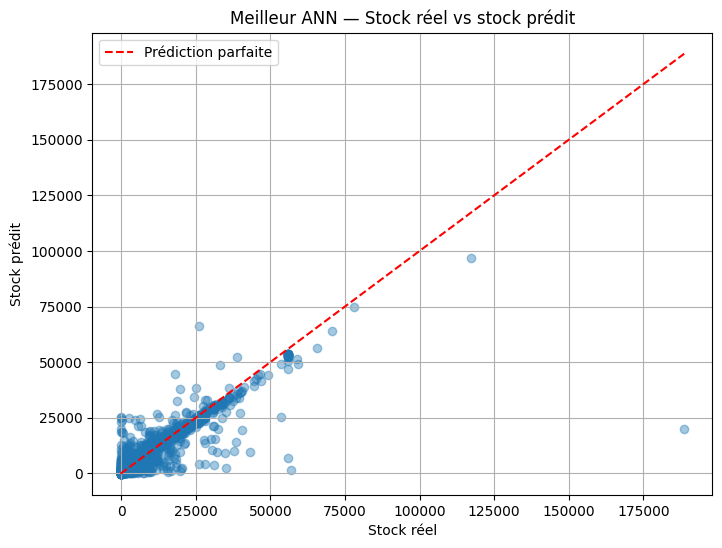

In [129]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_stock, y_pred_best_ann, alpha=0.4)

min_val = min(y_test_stock.min(), y_pred_best_ann.min())
max_val = max(y_test_stock.max(), y_pred_best_ann.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Prédiction parfaite')

plt.xlabel("Stock réel")
plt.ylabel("Stock prédit")
plt.title("Meilleur ANN — Stock réel vs stock prédit")
plt.legend()
plt.grid(True)
plt.show()

12. sauvegarde du meilleur modèle

In [201]:
import joblib

joblib.dump(best_ann_stock, f"{base_path}/stock_prediction_ann.pkl")
joblib.dump(scaler, f"{base_path}/stock_scaler.pkl")
print("Modèle ANN stock sauvegardé 🚀")

Modèle ANN stock sauvegardé 🚀


# nouvelle partie avec des nouveaux tables !


#partie 1 : segmentation des clients

Réaliser une analyse commerciale multidimensionnelle des ventes afin d’identifier les segments les plus performants selon les produits, clients, familles et zones, et mettre en évidence les structures de vente les plus stratégiques.

1. Charger et nettoyer les données

In [130]:
df = pd.read_csv(f"{base_path}/ca_tot_vente.csv")
print(df.shape)
df.head()

(543781, 13)


,id,ttc,ht,qte,qte_g,art,cl,date,dlg,fam,zone,created_at,id_crm
0,1222672,96.370,80.983,12,NaN,CANDEREL004,411C003,2019-08-21,NaN,Grossistes,BIZERTE,2024-03-15 11:01:38.000,20058
1,1222673,154.214,129.592,20,NaN,CANDEREL004,411C005,2019-02-28,NaN,Grossistes,SFAX 1A,2024-03-15 11:01:38.000,19601
2,1222674,370.115,311.021,48,NaN,CANDEREL004,411C007,2019-03-13,NaN,Grossistes,TUNIS 1A,2024-03-15 11:01:38.000,20168
3,1222675,50.890,42.765,6,NaN,CANDEREL004,411E004,2019-09-16,NaN,Grossistes,TUNIS 4,2024-03-15 11:01:38.000,20056
4,1222676,46.265,38.878,6,NaN,CANDEREL004,411E011,2019-02-14,NaN,Grossistes,MAHDIA,2024-03-15 11:01:38.000,20339


In [131]:
data = df.copy()

data["date"] = pd.to_datetime(data["date"], errors="coerce")

text_cols = ["art", "cl", "fam", "zone", "dlg"]
for col in text_cols:
    if col in data.columns:
        data[col] = data[col].astype(str).str.strip()
        data[col] = data[col].replace("nan", np.nan)

data = data.drop_duplicates()

data = data[
    data["date"].notna() &
    data["qte"].notna() &
    data["ttc"].notna() &
    data["ht"].notna()
].copy()

data = data[(data["qte"] >= 0) & (data["ttc"] >= 0) & (data["ht"] >= 0)].copy()

print(data.shape)
data.head()

(507764, 13)


,id,ttc,ht,qte,qte_g,art,cl,date,dlg,fam,zone,created_at,id_crm
0,1222672,96.370,80.983,12,NaN,CANDEREL004,411C003,2019-08-21,NaN,Grossistes,BIZERTE,2024-03-15 11:01:38.000,20058
1,1222673,154.214,129.592,20,NaN,CANDEREL004,411C005,2019-02-28,NaN,Grossistes,SFAX 1A,2024-03-15 11:01:38.000,19601
2,1222674,370.115,311.021,48,NaN,CANDEREL004,411C007,2019-03-13,NaN,Grossistes,TUNIS 1A,2024-03-15 11:01:38.000,20168
3,1222675,50.890,42.765,6,NaN,CANDEREL004,411E004,2019-09-16,NaN,Grossistes,TUNIS 4,2024-03-15 11:01:38.000,20056
4,1222676,46.265,38.878,6,NaN,CANDEREL004,411E011,2019-02-14,NaN,Grossistes,MAHDIA,2024-03-15 11:01:38.000,20339


2. Créer une table client

In [132]:
client_ml = data.groupby("cl", as_index=False).agg(
    ca_ttc=("ttc", "sum"),
    ca_ht=("ht", "sum"),
    qte_totale=("qte", "sum"),
    nb_transactions=("art", "count"),
    nb_articles=("art", "nunique"),
    nb_familles=("fam", "nunique"),
    nb_zones=("zone", "nunique"),
    nb_delegues=("dlg", "nunique"),
    first_purchase=("date", "min"),
    last_purchase=("date", "max")
)

client_ml["active_days"] = (client_ml["last_purchase"] - client_ml["first_purchase"]).dt.days
client_ml["active_days"] = client_ml["active_days"].fillna(0)

client_ml.head()

,cl,ca_ttc,ca_ht,qte_totale,nb_transactions,nb_articles,nb_familles,nb_zones,nb_delegues,first_purchase,last_purchase,active_days
0,411200,367768.855,309049.465,4229,86,4,1,1,7,2024-01-08,2026-01-14,737
1,411A001,2766845.531,2319222.079,319390,5728,357,1,1,15,2019-01-11,2026-01-19,2565
2,411A004,15386.469,12867.761,2634,87,46,1,1,2,2019-08-30,2020-07-09,314
3,411A005,450.961,378.960,10,3,1,1,1,1,2019-07-26,2020-02-21,210
4,411A006,102419.544,87649.275,41935,10,4,1,1,1,2021-02-16,2021-08-12,177


In [133]:
# ==============================
# Enrichissement des variables client
# ==============================

client_ml_v2 = client_ml.copy()

client_ml_v2["panier_moyen"] = client_ml_v2["ca_ttc"] / client_ml_v2["nb_transactions"].replace(0, 1)
client_ml_v2["qte_moy_par_transaction"] = client_ml_v2["qte_totale"] / client_ml_v2["nb_transactions"].replace(0, 1)
client_ml_v2["diversite_article"] = client_ml_v2["nb_articles"] / client_ml_v2["nb_transactions"].replace(0, 1)
client_ml_v2["diversite_famille"] = client_ml_v2["nb_familles"] / client_ml_v2["nb_transactions"].replace(0, 1)
client_ml_v2["intensite_achat"] = client_ml_v2["nb_transactions"] / (client_ml_v2["active_days"] + 1)

date_max = data["date"].max()
client_ml_v2["recence"] = (date_max - client_ml_v2["last_purchase"]).dt.days
client_ml_v2["anciennete"] = (date_max - client_ml_v2["first_purchase"]).dt.days

client_ml_v2.head()

,cl,ca_ttc,ca_ht,qte_totale,nb_transactions,nb_articles,nb_familles,nb_zones,nb_delegues,first_purchase,last_purchase,active_days,panier_moyen,qte_moy_par_transaction,diversite_article,diversite_famille,intensite_achat,recence,anciennete
0,411200,367768.855,309049.465,4229,86,4,1,1,7,2024-01-08,2026-01-14,737,4276.382035,49.174419,0.046512,0.011628,0.116531,8,745
1,411A001,2766845.531,2319222.079,319390,5728,357,1,1,15,2019-01-11,2026-01-19,2565,483.038675,55.759427,0.062325,0.000175,2.232268,3,2568
2,411A004,15386.469,12867.761,2634,87,46,1,1,2,2019-08-30,2020-07-09,314,176.855966,30.275862,0.528736,0.011494,0.276190,2023,2337
3,411A005,450.961,378.960,10,3,1,1,1,1,2019-07-26,2020-02-21,210,150.320333,3.333333,0.333333,0.333333,0.014218,2162,2372
4,411A006,102419.544,87649.275,41935,10,4,1,1,1,2021-02-16,2021-08-12,177,10241.954400,4193.500000,0.400000,0.100000,0.056180,1624,1801


3. Filtrage des clients trop faibles

In [134]:
client_ml_filtered = client_ml_v2[
    (client_ml_v2["nb_transactions"] >= 2) &
    (client_ml_v2["ca_ttc"] > 0)
].copy()

print("Avant filtrage :", client_ml_v2.shape)
print("Après filtrage :", client_ml_filtered.shape)

Avant filtrage : (1870, 19)
Après filtrage : (1488, 19)


4. Choix final des variables

In [135]:
features_cluster_rfm = [
    "ca_ttc",
    "nb_transactions",
    "recence",
    "anciennete",
    "panier_moyen",
    "qte_moy_par_transaction",
    "diversite_article",
    "intensite_achat"
]

X_rfm_f = client_ml_filtered[features_cluster_rfm].fillna(0).copy()
X_rfm_f.head()

,ca_ttc,nb_transactions,recence,anciennete,panier_moyen,qte_moy_par_transaction,diversite_article,intensite_achat
0,367768.855,86,8,745,4276.382035,49.174419,0.046512,0.116531
1,2766845.531,5728,3,2568,483.038675,55.759427,0.062325,2.232268
2,15386.469,87,2023,2337,176.855966,30.275862,0.528736,0.276190
3,450.961,3,2162,2372,150.320333,3.333333,0.333333,0.014218
4,102419.544,10,1624,1801,10241.954400,4193.500000,0.400000,0.056180


5. processing

In [137]:
from sklearn.preprocessing import RobustScaler
for col in X_rfm_f.columns:
    low = X_rfm_f[col].quantile(0.01)
    high = X_rfm_f[col].quantile(0.99)
    X_rfm_f[col] = X_rfm_f[col].clip(lower=low, upper=high)

X_rfm_f_log = np.log1p(X_rfm_f)

scaler_rfm_f = RobustScaler()
X_scaled_rfm_f = scaler_rfm_f.fit_transform(X_rfm_f_log)

print(X_scaled_rfm_f.shape)

(1488, 8)


6. méthode de coude

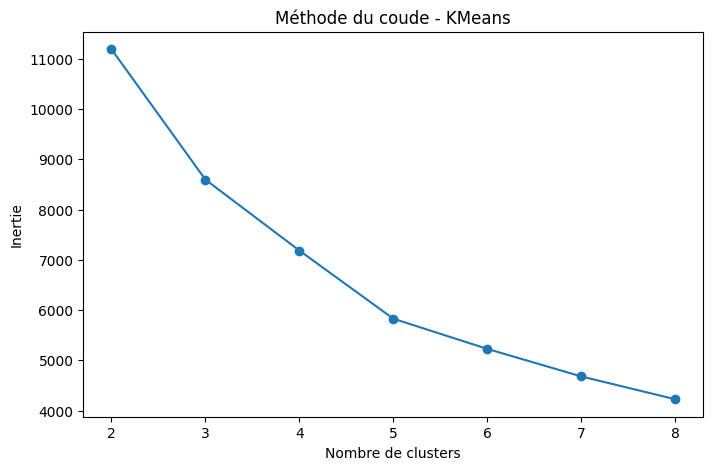

In [138]:
inertias = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled_rfm_f)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 9), inertias, marker="o")
plt.title("Méthode du coude - KMeans")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.show()

7. tester Kmeans avec plusieurs k

In [139]:
results_rfm_f = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled_rfm_f)
    sil = silhouette_score(X_scaled_rfm_f, labels)
    counts = pd.Series(labels).value_counts()

    results_rfm_f.append({
        "k": k,
        "silhouette_score": round(sil, 4),
        "cluster_min_size": int(counts.min()),
        "cluster_max_size": int(counts.max()),
        "imbalance_ratio": round(counts.max() / counts.min(), 2)
    })

results_rfm_f_df = pd.DataFrame(results_rfm_f)
display(results_rfm_f_df.sort_values(["silhouette_score", "imbalance_ratio"], ascending=[False, True]))

,k,silhouette_score,cluster_min_size,cluster_max_size,imbalance_ratio
0,2,0.7461,158,1330,8.42
1,3,0.5351,138,1196,8.67
3,5,0.3039,69,810,11.74
5,7,0.2896,75,514,6.85
2,4,0.2814,124,763,6.15
6,8,0.2745,50,497,9.94
4,6,0.2680,69,584,8.46


8. KMeans K=2

In [140]:
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=20)
client_ml_filtered["cluster_k2"] = kmeans_k2.fit_predict(X_scaled_rfm_f)

print(client_ml_filtered["cluster_k2"].value_counts().sort_index())

sil_k2 = silhouette_score(X_scaled_rfm_f, client_ml_filtered["cluster_k2"])
print("Silhouette Score - KMeans k=2 :", round(sil_k2, 4))

cluster_k2
0    1330
1     158
Name: count, dtype: int64
Silhouette Score - KMeans k=2 : 0.7461


In [141]:
cluster_profile_k2 = client_ml_filtered.groupby("cluster_k2")[features_cluster_rfm].mean().round(2)
display(cluster_profile_k2)

,ca_ttc,nb_transactions,recence,anciennete,panier_moyen,qte_moy_par_transaction,diversite_article,intensite_achat
cluster_k2,,,,,,,,
0,140899.01,350.81,559.89,1943.09,208.05,26.81,0.57,0.26
1,148285.23,210.10,1184.82,1221.01,177.28,23.12,0.98,23.05


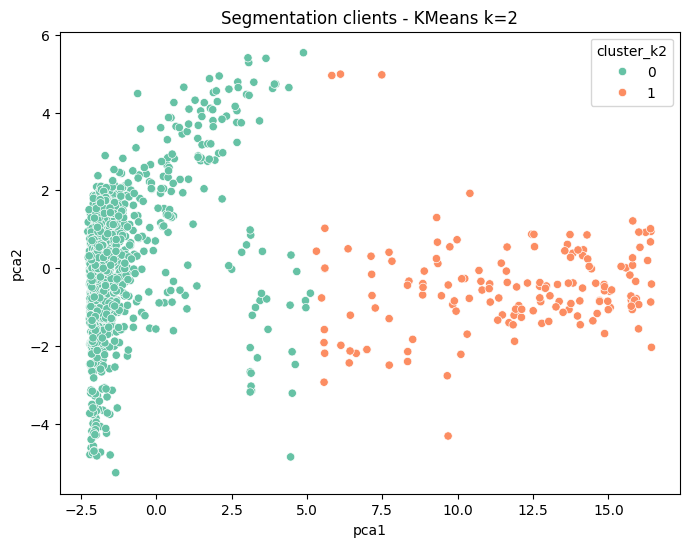

In [142]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_rfm_f)

client_ml_filtered["pca1"] = X_pca[:, 0]
client_ml_filtered["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=client_ml_filtered,
    x="pca1",
    y="pca2",
    hue="cluster_k2",
    palette="Set2"
)
plt.title("Segmentation clients - KMeans k=2")
plt.show()

9. KMeans K=3

In [143]:
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=20)
client_ml_filtered["cluster_k3"] = kmeans_k3.fit_predict(X_scaled_rfm_f)

print(client_ml_filtered["cluster_k3"].value_counts().sort_index())

sil_k3 = silhouette_score(X_scaled_rfm_f, client_ml_filtered["cluster_k3"])
print("Silhouette Score - KMeans k=3 :", round(sil_k3, 4))

cluster_k3
0    1196
1     138
2     154
Name: count, dtype: int64
Silhouette Score - KMeans k=3 : 0.5351


In [144]:
cluster_profile_k3 = client_ml_filtered.groupby("cluster_k3")[features_cluster_rfm].mean().round(2)
display(cluster_profile_k3)

,ca_ttc,nb_transactions,recence,anciennete,panier_moyen,qte_moy_par_transaction,diversite_article,intensite_achat
cluster_k3,,,,,,,,
0,25600.49,156.53,567.69,1935.78,182.84,24.03,0.59,0.12
1,4261.84,26.92,1159.94,1160.06,155.49,17.75,0.99,25.71
2,1166353.44,2005.53,602.78,1960.71,419.35,52.69,0.40,1.95


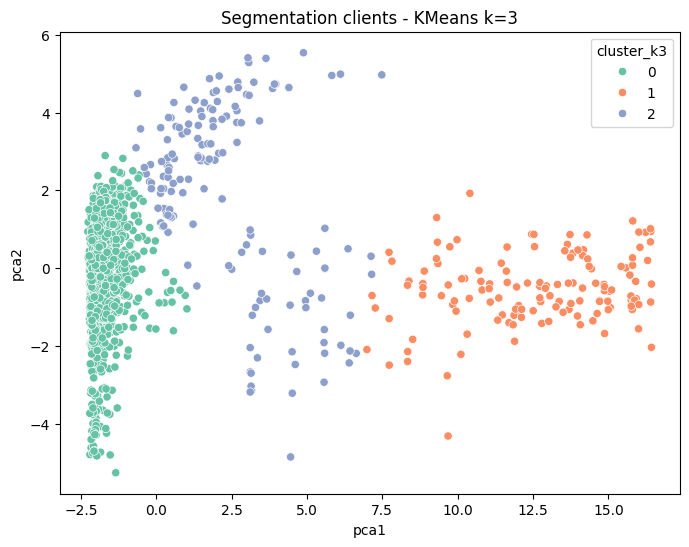

In [145]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=client_ml_filtered,
    x="pca1",
    y="pca2",
    hue="cluster_k3",
    palette="Set2"
)
plt.title("Segmentation clients - KMeans k=3")
plt.show()

In [146]:
# ==============================
# KMeans
# ==============================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

kmeans_results = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled_rfm_f)
    counts = pd.Series(labels).value_counts()

    kmeans_results.append({
        "modele": "KMeans",
        "configuration": f"k={k}",
        "silhouette_score": round(silhouette_score(X_scaled_rfm_f, labels), 4),
        "cluster_min_size": int(counts.min()),
        "cluster_max_size": int(counts.max())
    })

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df.sort_values("silhouette_score", ascending=False))

,modele,configuration,silhouette_score,cluster_min_size,cluster_max_size
0,KMeans,k=2,0.7461,158,1330
1,KMeans,k=3,0.5351,138,1196
3,KMeans,k=5,0.3039,69,810
5,KMeans,k=7,0.2896,75,514
2,KMeans,k=4,0.2814,124,763
6,KMeans,k=8,0.2745,50,497
4,KMeans,k=6,0.2680,69,584


modèle 2 : Agglomerative

In [147]:
# ==============================
# Agglomerative Clustering
# ==============================

from sklearn.cluster import AgglomerativeClustering

agg_results = []

for linkage in ["ward", "complete", "average"]:
    for k in range(2, 9):
        if linkage == "ward":
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        else:
            model = AgglomerativeClustering(n_clusters=k, linkage=linkage, metric="euclidean")

        labels = model.fit_predict(X_scaled_rfm_f)
        counts = pd.Series(labels).value_counts()

        agg_results.append({
            "modele": "Agglomerative",
            "configuration": f"linkage={linkage}, k={k}",
            "silhouette_score": round(silhouette_score(X_scaled_rfm_f, labels), 4),
            "cluster_min_size": int(counts.min()),
            "cluster_max_size": int(counts.max())
        })

agg_results_df = pd.DataFrame(agg_results)
display(agg_results_df.sort_values("silhouette_score", ascending=False))

,modele,configuration,silhouette_score,cluster_min_size,cluster_max_size
0,Agglomerative,"linkage=ward, k=2",0.7503,132,1356
7,Agglomerative,"linkage=complete, k=2",0.7477,133,1355
14,Agglomerative,"linkage=average, k=2",0.7230,183,1305
15,Agglomerative,"linkage=average, k=3",0.6320,78,1305
16,Agglomerative,"linkage=average, k=4",0.6238,10,1305
8,Agglomerative,"linkage=complete, k=3",0.5962,69,1286
9,Agglomerative,"linkage=complete, k=4",0.5656,5,1286
10,Agglomerative,"linkage=complete, k=5",0.5616,5,1286
17,Agglomerative,"linkage=average, k=5",0.5434,10,1245
1,Agglomerative,"linkage=ward, k=3",0.5388,132,1195


modèle 3 : Gaussian Mixture

In [148]:
# ==============================
# Gaussian Mixture
# ==============================

from sklearn.mixture import GaussianMixture

gmm_results = []

for cov in ["full", "tied", "diag", "spherical"]:
    for k in range(2, 9):
        model = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
        labels = model.fit_predict(X_scaled_rfm_f)
        counts = pd.Series(labels).value_counts()

        gmm_results.append({
            "modele": "Gaussian Mixture",
            "configuration": f"covariance={cov}, k={k}",
            "silhouette_score": round(silhouette_score(X_scaled_rfm_f, labels), 4),
            "cluster_min_size": int(counts.min()),
            "cluster_max_size": int(counts.max())
        })

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.sort_values("silhouette_score", ascending=False))

,modele,configuration,silhouette_score,cluster_min_size,cluster_max_size
7,Gaussian Mixture,"covariance=tied, k=2",0.7314,172,1316
8,Gaussian Mixture,"covariance=tied, k=3",0.6169,67,1302
0,Gaussian Mixture,"covariance=full, k=2",0.6057,252,1236
21,Gaussian Mixture,"covariance=spherical, k=2",0.5754,337,1151
9,Gaussian Mixture,"covariance=tied, k=4",0.5323,68,1226
14,Gaussian Mixture,"covariance=diag, k=2",0.5110,327,1161
10,Gaussian Mixture,"covariance=tied, k=5",0.4373,54,1172
22,Gaussian Mixture,"covariance=spherical, k=3",0.4229,137,1030
23,Gaussian Mixture,"covariance=spherical, k=4",0.3422,113,893
1,Gaussian Mixture,"covariance=full, k=3",0.3246,157,976


modèle 4 : DBSCAN

In [149]:
# ==============================
# DBSCAN
# ==============================

from sklearn.cluster import DBSCAN
import numpy as np

dbscan_results = []

for eps in [0.3, 0.5, 0.7, 0.9, 1.1]:
    for min_samples in [3, 5, 10]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled_rfm_f)

        n_clusters = len(set(labels) - {-1})
        noise_points = list(labels).count(-1)

        if n_clusters >= 2:
            mask = labels != -1
            counts = pd.Series(labels[mask]).value_counts()

            dbscan_results.append({
                "modele": "DBSCAN",
                "configuration": f"eps={eps}, min_samples={min_samples}",
                "silhouette_score": round(silhouette_score(X_scaled_rfm_f[mask], labels[mask]), 4),
                "cluster_min_size": int(counts.min()),
                "cluster_max_size": int(counts.max()),
                "n_clusters": int(n_clusters),
                "noise_points": int(noise_points)
            })

dbscan_results_df = pd.DataFrame(dbscan_results)
display(dbscan_results_df.sort_values("silhouette_score", ascending=False))

,modele,configuration,silhouette_score,cluster_min_size,cluster_max_size,n_clusters,noise_points
11,DBSCAN,"eps=1.1, min_samples=10",0.8099,8,1184,3,286
10,DBSCAN,"eps=1.1, min_samples=5",0.5111,5,1220,5,169
6,DBSCAN,"eps=0.7, min_samples=5",0.4927,4,1005,5,462
1,DBSCAN,"eps=0.3, min_samples=5",0.3487,5,17,10,1416
8,DBSCAN,"eps=0.9, min_samples=5",0.2947,4,1157,9,267
3,DBSCAN,"eps=0.5, min_samples=5",0.2433,5,684,3,792
9,DBSCAN,"eps=1.1, min_samples=3",0.2238,3,1240,13,112
0,DBSCAN,"eps=0.3, min_samples=3",0.2121,3,43,39,1261
7,DBSCAN,"eps=0.9, min_samples=3",0.1501,3,1177,21,191
4,DBSCAN,"eps=0.5, min_samples=10",0.0627,10,517,2,961


comparaison

In [150]:
# ==============================
# Comparaison finale
# ==============================

best_kmeans = kmeans_results_df.sort_values("silhouette_score", ascending=False).head(1)
best_agg = agg_results_df.sort_values("silhouette_score", ascending=False).head(1)
best_gmm = gmm_results_df.sort_values("silhouette_score", ascending=False).head(1)
best_dbscan = dbscan_results_df.sort_values("silhouette_score", ascending=False).head(1)

comparison_all_models = pd.concat(
    [best_kmeans, best_agg, best_gmm, best_dbscan],
    ignore_index=True
)

display(comparison_all_models.sort_values("silhouette_score", ascending=False))

,modele,configuration,silhouette_score,cluster_min_size,cluster_max_size,n_clusters,noise_points
3,DBSCAN,"eps=1.1, min_samples=10",0.8099,8,1184,3.0,286.0
1,Agglomerative,"linkage=ward, k=2",0.7503,132,1356,NaN,NaN
0,KMeans,k=2,0.7461,158,1330,NaN,NaN
2,Gaussian Mixture,"covariance=tied, k=2",0.7314,172,1316,NaN,NaN


# partie XAI !!

## Choix du modèle final

Après comparaison des modèles de clustering, DBSCAN a obtenu le meilleur silhouette score. Ce modèle est retenu comme modèle final pour la segmentation des clients.

1. création des clusters finaux

In [151]:
from sklearn.cluster import DBSCAN

best_model = DBSCAN(eps=1.1, min_samples=10)
client_ml_filtered["cluster_final"] = best_model.fit_predict(X_scaled_rfm_f)

print(client_ml_filtered["cluster_final"].value_counts().sort_index())

cluster_final
-1     286
 0    1184
 1      10
 2       8
Name: count, dtype: int64


2. XAI - Interprétation des segments clients

In [152]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# on retire les points bruit DBSCAN (-1) pour l'explication
xai_clients = client_ml_filtered[client_ml_filtered["cluster_final"] != -1].copy()

X_xai_clients = xai_clients[features_cluster_rfm].fillna(0)
y_xai_clients = xai_clients["cluster_final"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_xai_clients,
    y_xai_clients,
    test_size=0.2,
    random_state=42,
    stratify=y_xai_clients
)

xai_model_clients = RandomForestClassifier(n_estimators=200, random_state=42)
xai_model_clients.fit(X_train_c, y_train_c)

y_pred_c = xai_model_clients.predict(X_test_c)

print("Accuracy XAI - Clients :", round(accuracy_score(y_test_c, y_pred_c), 4))
print("\nClassification report :\n")
print(classification_report(y_test_c, y_pred_c))

Accuracy XAI - Clients : 1.0

Classification report :

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       237
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2

    accuracy                           1.00       241
   macro avg       1.00      1.00      1.00       241
weighted avg       1.00      1.00      1.00       241



3. importance des variables

,feature,importance
7,intensite_achat,0.492179
3,anciennete,0.124716
1,nb_transactions,0.114433
0,ca_ttc,0.069128
2,recence,0.059759
6,diversite_article,0.056541
4,panier_moyen,0.046442
5,qte_moy_par_transaction,0.036803


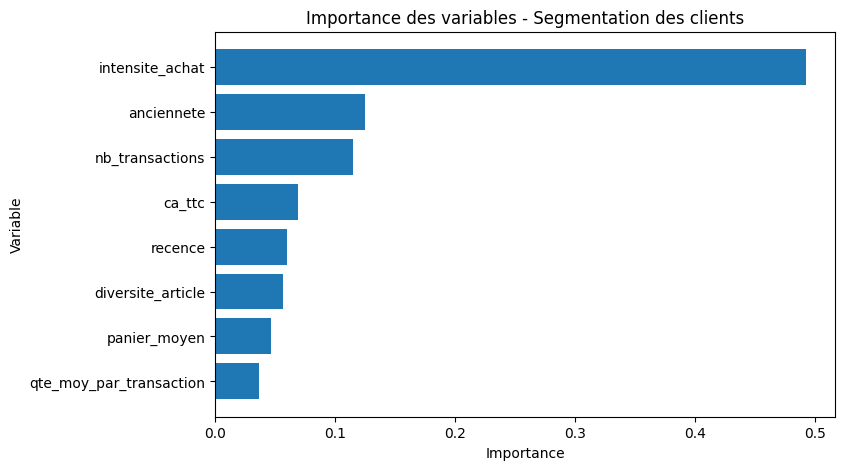

In [153]:
importance_clients = pd.DataFrame({
    "feature": features_cluster_rfm,
    "importance": xai_model_clients.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_clients)

plt.figure(figsize=(8,5))
plt.barh(importance_clients["feature"], importance_clients["importance"])
plt.gca().invert_yaxis()
plt.title("Importance des variables - Segmentation des clients")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

### Interprétation XAI

Les résultats montrent que l’intensité d’achat est la variable la plus déterminante dans la formation des segments clients, suivie par l’ancienneté et le nombre de transactions.  
Cela signifie que la segmentation obtenue repose principalement sur le comportement d’achat et la durée de relation client.  
L’accuracy élevée du modèle explicatif confirme que les clusters identifiés sont nettement séparables.

sauvegarde du meilleur modèle

In [211]:
from sklearn.cluster import DBSCAN
import joblib

best_model = DBSCAN(eps=1.1, min_samples=10)
best_model.fit(X_scaled_rfm_f)

joblib.dump(best_model, f"{base_path}/dbscan_segmentation_client.pkl")
print("Modèle sauvegardé dans Google Drive.")

Modèle sauvegardé dans Google Drive.


#partie 2 : segmentation des zones

1. import

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

2. charger les tables

In [155]:
gro = pd.read_csv(f"{base_path}/ca_prd_gro_zone.csv")
ph = pd.read_csv(f"{base_path}/ca_prd_ph_zone.csv")
print("Shape GRO :", gro.shape)
print("Shape PH  :", ph.shape)

display(gro.head())
display(ph.head())

Shape GRO : (185858, 8)
Shape PH  : (185858, 8)


,id,article,year,secteur,ca,qte,created_at,bu
0,1182967,433,2021,18,276302.636,16251.853,2021-12-31 23:30:30.000,0
1,1182930,433,2021,37,190720.390,11110.856,2021-12-31 23:30:06.000,0
2,34034836,176,2025,18,167390.191,8256.707,2025-12-31 23:14:09.000,8
3,1182947,433,2021,25,157227.995,9159.679,2021-12-31 23:30:17.000,0
4,1183000,433,2021,6,152712.534,8929.679,2021-12-31 23:30:50.000,0


,id,article,year,secteur,ca,qte,created_at,bu
0,22056109,608,2024,10,-3353.114,-188.0,2024-12-31 23:14:39.000,11
1,16758250,586,2023,10,-2057.717,-266.0,2024-01-04 22:26:06.000,10
2,1140527,180,2021,52,-1987.115,-197.0,2021-12-31 04:13:57.000,0
3,34594867,15,2025,9,-1804.998,-202.0,2025-12-31 23:00:40.000,9
4,1152117,391,2021,40,-1718.853,-500.0,2021-12-31 04:25:55.000,0


3. nettoyage

In [156]:
def clean_zone_table(df):
    data = df.copy()

    for col in ["article", "secteur", "bu"]:
        if col in data.columns:
            data[col] = data[col].astype(str).str.strip()
            data[col] = data[col].replace("nan", np.nan)

    for col in ["year", "ca", "qte"]:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    data = data.drop_duplicates()

    data = data[
        data["secteur"].notna() &
        data["article"].notna() &
        data["year"].notna() &
        data["ca"].notna() &
        data["qte"].notna()
    ].copy()

    # On garde les valeurs positives ou nulles
    data = data[(data["ca"] >= 0) & (data["qte"] >= 0)].copy()
    return data
gro_data = clean_zone_table(gro)
ph_data = clean_zone_table(ph)

print("Shape GRO nettoyé :", gro_data.shape)
print("Shape PH nettoyé  :", ph_data.shape)
print("Nombre de secteurs GRO :", gro_data["secteur"].nunique())
print("Nombre de secteurs PH  :", ph_data["secteur"].nunique())

Shape GRO nettoyé : (174415, 8)
Shape PH nettoyé  : (184748, 8)
Nombre de secteurs GRO : 73
Nombre de secteurs PH  : 73


4. construction par zone

In [157]:
def build_zone_ml(data):
    zone_ml = data.groupby("secteur", as_index=False).agg(
        ca_total=("ca", "sum"),
        qte_totale=("qte", "sum"),
        nb_articles=("article", "nunique"),
        nb_lignes=("article", "count"),
        nb_years=("year", "nunique"),
        nb_bu=("bu", "nunique"),
        ca_moyen_par_ligne=("ca", "mean"),
        qte_moyenne_par_ligne=("qte", "mean")
    )

    zone_ml["ca_par_article"] = zone_ml["ca_total"] / zone_ml["nb_articles"]
    zone_ml["qte_par_article"] = zone_ml["qte_totale"] / zone_ml["nb_articles"]
    zone_ml["lignes_par_article"] = zone_ml["nb_lignes"] / zone_ml["nb_articles"]

    zone_ml = zone_ml.replace([np.inf, -np.inf], np.nan).fillna(0)

    return zone_ml

gro_zone_ml = build_zone_ml(gro_data)
ph_zone_ml = build_zone_ml(ph_data)

print("Shape gro_zone_ml :", gro_zone_ml.shape)
print("Shape ph_zone_ml  :", ph_zone_ml.shape)

display(gro_zone_ml.head())
display(ph_zone_ml.head())

Shape gro_zone_ml : (73, 12)
Shape ph_zone_ml  : (73, 12)


,secteur,ca_total,qte_totale,nb_articles,nb_lignes,nb_years,nb_bu,ca_moyen_par_ligne,qte_moyenne_par_ligne,ca_par_article,qte_par_article,lignes_par_article
0,1,2106707.496,227068.875,532,2416,6,5,871.981579,93.985462,3959.976496,426.821194,4.541353
1,10,445263.377,47503.264,532,2418,6,5,184.145317,19.645684,836.961235,89.291850,4.545113
2,11,3257401.516,348049.299,532,2416,6,5,1348.262217,144.060140,6122.935180,654.228006,4.541353
3,12,2582013.232,266905.931,533,2360,6,5,1094.073403,113.095733,4844.302499,500.761597,4.427767
4,13,3036815.046,323035.050,533,2386,6,5,1272.764060,135.387699,5697.589205,606.069512,4.476548


,secteur,ca_total,qte_totale,nb_articles,nb_lignes,nb_years,nb_bu,ca_moyen_par_ligne,qte_moyenne_par_ligne,ca_par_article,qte_par_article,lignes_par_article
0,1,220729.773,23203.0,533,2533,6,5,87.141640,9.160284,414.127154,43.532833,4.752345
1,10,392832.974,19042.0,533,2437,6,5,161.195311,7.813705,737.022465,35.726079,4.572233
2,11,363064.786,40151.0,533,2532,6,5,143.390516,15.857425,681.172206,75.330206,4.750469
3,12,490734.237,47462.0,533,2532,6,5,193.812890,18.744866,920.702133,89.046904,4.750469
4,13,414973.668,50618.0,533,2535,6,5,163.697699,19.967653,778.562229,94.968105,4.756098


5. Variables de segmentation

In [158]:
features_zone = [
    "ca_total",
    "qte_totale",
    "nb_articles",
    "nb_lignes",
    "nb_years",
    "nb_bu",
    "ca_moyen_par_ligne",
    "qte_moyenne_par_ligne",
    "ca_par_article",
    "qte_par_article",
    "lignes_par_article"
]

6.  Préparer Grossistes et Pharmacies

In [159]:
def prepare_features(zone_ml, features):
    X = np.log1p(zone_ml[features].fillna(0))
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X, X_scaled, scaler

X_gro, X_gro_scaled, scaler_gro = prepare_features(gro_zone_ml, features_zone)
X_ph, X_ph_scaled, scaler_ph = prepare_features(ph_zone_ml, features_zone)

7. Fonction pour tester KMeans sur plusieurs k

In [160]:
def find_best_k_kmeans(X_scaled, max_k=8):
    scores = []
    max_k = min(max_k, len(X_scaled) - 1)

    for k in range(2, max_k + 1):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        scores.append((k, score))

    return pd.DataFrame(scores, columns=["k", "silhouette_score"])

8. Chercher le meilleur k pour Grossistes

,k,silhouette_score
0,2,0.558122
1,3,0.499223
2,4,0.426789
3,5,0.460412
4,6,0.450175
5,7,0.447375
6,8,0.472981


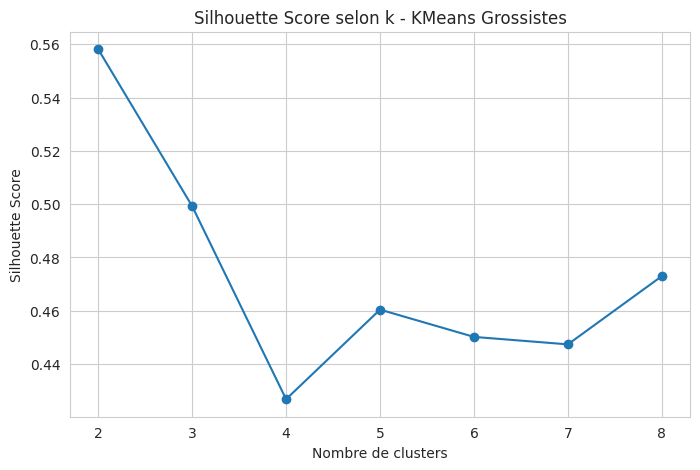

Meilleur k Grossistes : 2


In [161]:
score_gro_kmeans = find_best_k_kmeans(X_gro_scaled, max_k=8)
display(score_gro_kmeans)
plt.figure(figsize=(8,5))
plt.plot(score_gro_kmeans["k"], score_gro_kmeans["silhouette_score"], marker="o")
plt.title("Silhouette Score selon k - KMeans Grossistes")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette Score")
plt.show()
best_k_gro = int(score_gro_kmeans.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
print("Meilleur k Grossistes :", best_k_gro)

9. Chercher le meilleur k pour Pharmacies

,k,silhouette_score
0,2,0.507957
1,3,0.469400
2,4,0.468702
3,5,0.413733
4,6,0.372545
5,7,0.396650
6,8,0.363690


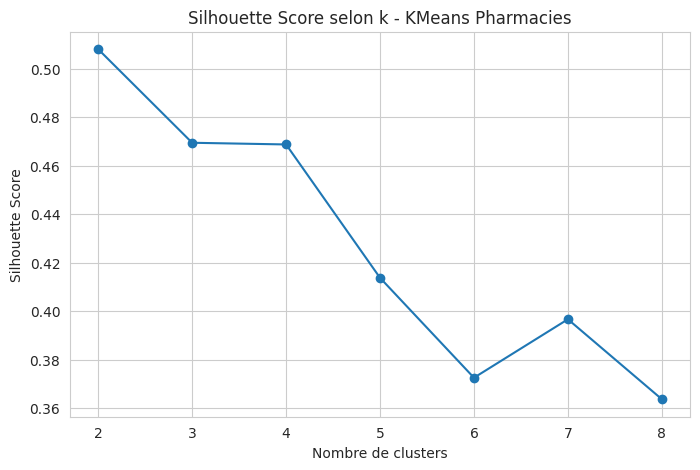

Meilleur k Pharmacies : 2


In [162]:
score_ph_kmeans = find_best_k_kmeans(X_ph_scaled, max_k=8)
display(score_ph_kmeans)
plt.figure(figsize=(8,5))
plt.plot(score_ph_kmeans["k"], score_ph_kmeans["silhouette_score"], marker="o")
plt.title("Silhouette Score selon k - KMeans Pharmacies")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette Score")
plt.show()
best_k_ph = int(score_ph_kmeans.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
print("Meilleur k Pharmacies :", best_k_ph)

10. Fonction pour entraîner les 3 modèles de clustering

In [163]:
def run_clustering_models(zone_ml, X_scaled, best_k, prefix=""):
    # KMeans
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    zone_ml[f"{prefix}cluster_kmeans"] = kmeans.fit_predict(X_scaled)
    sil_kmeans = silhouette_score(X_scaled, zone_ml[f"{prefix}cluster_kmeans"])

    # Agglomerative
    agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
    zone_ml[f"{prefix}cluster_agg"] = agg.fit_predict(X_scaled)
    sil_agg = silhouette_score(X_scaled, zone_ml[f"{prefix}cluster_agg"])

    # GMM
    gmm = GaussianMixture(n_components=best_k, random_state=42)
    zone_ml[f"{prefix}cluster_gmm"] = gmm.fit_predict(X_scaled)
    sil_gmm = silhouette_score(X_scaled, zone_ml[f"{prefix}cluster_gmm"])

    return zone_ml, sil_kmeans, sil_agg, sil_gmm

11. Clustering sur Grossistes

In [164]:
gro_zone_ml, sil_gro_kmeans, sil_gro_agg, sil_gro_gmm = run_clustering_models(
    gro_zone_ml, X_gro_scaled, best_k_gro, prefix="gro_"
)

print("Silhouette Grossistes - KMeans       :", round(sil_gro_kmeans, 4))
print("Silhouette Grossistes - Agglomerative:", round(sil_gro_agg, 4))
print("Silhouette Grossistes - GMM          :", round(sil_gro_gmm, 4))

Silhouette Grossistes - KMeans       : 0.5581
Silhouette Grossistes - Agglomerative: 0.6012
Silhouette Grossistes - GMM          : 0.5285


12. Clustering sur Pharmacies

In [165]:
ph_zone_ml, sil_ph_kmeans, sil_ph_agg, sil_ph_gmm = run_clustering_models(
    ph_zone_ml, X_ph_scaled, best_k_ph, prefix="ph_"
)

print("Silhouette Pharmacies - KMeans       :", round(sil_ph_kmeans, 4))
print("Silhouette Pharmacies - Agglomerative:", round(sil_ph_agg, 4))
print("Silhouette Pharmacies - GMM          :", round(sil_ph_gmm, 4))

Silhouette Pharmacies - KMeans       : 0.508
Silhouette Pharmacies - Agglomerative: 0.508
Silhouette Pharmacies - GMM          : 0.5138


13. Fonction tableau comparatif

In [166]:
def clustering_summary(df, label_col, model_name, silhouette_value):
    counts = df[label_col].value_counts().sort_index()

    return {
        "modele": model_name,
        "n_clusters": counts.shape[0],
        "silhouette_score": round(silhouette_value, 4),
        "cluster_min_size": int(counts.min()),
        "cluster_max_size": int(counts.max()),
        "cluster_mean_size": round(counts.mean(), 2),
        "cluster_std_size": round(counts.std(), 2),
        "imbalance_ratio": round(counts.max() / counts.min(), 2) if counts.min() != 0 else np.nan
    }

14. Comparaison des modèles Grossistes

In [167]:
comparison_gro = pd.DataFrame([
    clustering_summary(gro_zone_ml, "gro_cluster_kmeans", "KMeans", sil_gro_kmeans),
    clustering_summary(gro_zone_ml, "gro_cluster_agg", "Agglomerative", sil_gro_agg),
    clustering_summary(gro_zone_ml, "gro_cluster_gmm", "GMM", sil_gro_gmm)
])

display(comparison_gro.sort_values("silhouette_score", ascending=False))

,modele,n_clusters,silhouette_score,cluster_min_size,cluster_max_size,cluster_mean_size,cluster_std_size,imbalance_ratio
1,Agglomerative,2,0.6012,4,69,36.5,45.96,17.25
0,KMeans,2,0.5581,6,67,36.5,43.13,11.17
2,GMM,2,0.5285,7,66,36.5,41.72,9.43


15. Comparaison des modèles Pharmacies

In [168]:
comparison_ph = pd.DataFrame([
    clustering_summary(ph_zone_ml, "ph_cluster_kmeans", "KMeans", sil_ph_kmeans),
    clustering_summary(ph_zone_ml, "ph_cluster_agg", "Agglomerative", sil_ph_agg),
    clustering_summary(ph_zone_ml, "ph_cluster_gmm", "GMM", sil_ph_gmm)
])

display(comparison_ph.sort_values("silhouette_score", ascending=False))

,modele,n_clusters,silhouette_score,cluster_min_size,cluster_max_size,cluster_mean_size,cluster_std_size,imbalance_ratio
2,GMM,2,0.5138,15,58,36.5,30.41,3.87
0,KMeans,2,0.5080,17,56,36.5,27.58,3.29
1,Agglomerative,2,0.5080,17,56,36.5,27.58,3.29


16. modele finale

In [169]:
gro_zone_ml["cluster_final"] = gro_zone_ml["gro_cluster_agg"]
ph_zone_ml["cluster_final"] = ph_zone_ml["ph_cluster_gmm"]

17. afficher le résumé final des clusters

In [170]:
#grossiste
gro_cluster_summary = gro_zone_ml.groupby("cluster_final").agg(
    nb_secteurs=("secteur", "count"),
    ca_moyen=("ca_total", "mean"),
    qte_moyenne=("qte_totale", "mean"),
    articles_moyens=("nb_articles", "mean"),
    lignes_moyennes=("nb_lignes", "mean"),
    annees_moyennes=("nb_years", "mean"),
    bu_moyennes=("nb_bu", "mean"),
    ca_moyen_ligne=("ca_moyen_par_ligne", "mean"),
    qte_moyenne_ligne=("qte_moyenne_par_ligne", "mean")
).round(2)

display(gro_cluster_summary)

,nb_secteurs,ca_moyen,qte_moyenne,articles_moyens,lignes_moyennes,annees_moyennes,bu_moyennes,ca_moyen_ligne,qte_moyenne_ligne
cluster_final,,,,,,,,,
0,69,1978931.67,210102.03,532.62,2390.03,6.0,5.0,828.15,87.91
1,4,113201.57,11890.58,533.00,2375.75,6.0,5.0,47.56,4.99


In [171]:
#pharmacie
ph_cluster_summary = ph_zone_ml.groupby("cluster_final").agg(
    nb_secteurs=("secteur", "count"),
    ca_moyen=("ca_total", "mean"),
    qte_moyenne=("qte_totale", "mean"),
    articles_moyens=("nb_articles", "mean"),
    lignes_moyennes=("nb_lignes", "mean"),
    annees_moyennes=("nb_years", "mean"),
    bu_moyennes=("nb_bu", "mean"),
    ca_moyen_ligne=("ca_moyen_par_ligne", "mean"),
    qte_moyenne_ligne=("qte_moyenne_par_ligne", "mean")
).round(2)

display(ph_cluster_summary)

,nb_secteurs,ca_moyen,qte_moyenne,articles_moyens,lignes_moyennes,annees_moyennes,bu_moyennes,ca_moyen_ligne,qte_moyenne_ligne
cluster_final,,,,,,,,,
0,15,79670.92,9027.87,533.0,2540.67,6.0,5.0,31.36,3.55
1,58,396919.91,42305.88,533.0,2528.24,6.0,5.0,157.15,16.74


18. voir quels secteurs appartiennent à chaque cluster

In [172]:
#grossiste
display(
    gro_zone_ml[["secteur", "cluster_final"] + features_zone]
    .sort_values(["cluster_final", "ca_total"], ascending=[True, False])
)

,secteur,cluster_final,ca_total,qte_totale,nb_articles,nb_lignes,nb_years,nb_bu,ca_moyen_par_ligne,qte_moyenne_par_ligne,ca_par_article,qte_par_article,lignes_par_article
9,18,0,8135810.918,855294.070,533,2360,6,5,3447.377508,362.412742,15264.185587,1604.679306,4.427767
30,37,0,6534382.965,698645.904,532,2416,6,5,2704.628711,289.174629,12282.674746,1313.244180,4.541353
44,5,0,4778950.021,507949.787,533,2386,6,5,2002.912834,212.887589,8966.135124,953.001477,4.476548
55,6,0,4495740.339,480451.169,533,2385,6,5,1885.006431,201.447031,8434.784876,901.409323,4.474672
38,44,0,3670534.018,387247.333,533,2360,6,5,1555.311025,164.087853,6886.555381,726.542839,4.427767
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,73,0,330878.929,34328.917,533,2360,6,5,140.202936,14.546151,620.785983,64.406974,4.427767
31,38,1,203762.531,21529.073,533,2386,6,5,85.399217,9.023082,382.293679,40.392257,4.476548
32,39,1,127189.860,13525.520,533,2387,6,5,53.284399,5.666326,238.630131,25.376210,4.478424
67,70,1,99441.435,10170.795,533,2364,6,5,42.064905,4.302367,186.569296,19.082167,4.435272


In [173]:
#pharmacie
display(
    ph_zone_ml[["secteur", "cluster_final"] + features_zone]
    .sort_values(["cluster_final", "ca_total"], ascending=[True, False])
)

,secteur,cluster_final,ca_total,qte_totale,nb_articles,nb_lignes,nb_years,nb_bu,ca_moyen_par_ligne,qte_moyenne_par_ligne,ca_par_article,qte_par_article,lignes_par_article
67,70,0,127798.474,14050.0,533,2546,6,5,50.195787,5.518460,239.771996,26.360225,4.776735
59,63,0,122591.501,12601.0,533,2543,6,5,48.207433,4.955171,230.002816,23.641651,4.771107
41,47,0,119908.216,12478.0,533,2534,6,5,47.319738,4.924230,224.968510,23.410882,4.754221
70,73,0,110386.271,12233.0,533,2545,6,5,43.373780,4.806680,207.103698,22.951220,4.774859
40,46,0,109107.027,10758.0,533,2541,6,5,42.938617,4.233766,204.703615,20.183865,4.767355
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,66,1,200386.254,20981.0,533,2535,6,5,79.047832,8.276529,375.959201,39.363977,4.756098
29,36,1,194230.408,17048.0,533,2520,6,5,77.075559,6.765079,364.409771,31.984991,4.727955
64,68,1,181415.995,18061.0,533,2509,6,5,72.306096,7.198485,340.367720,33.885553,4.707317
45,50,1,154333.048,16410.0,533,2537,6,5,60.832892,6.468270,289.555437,30.787992,4.759850


19. PCA

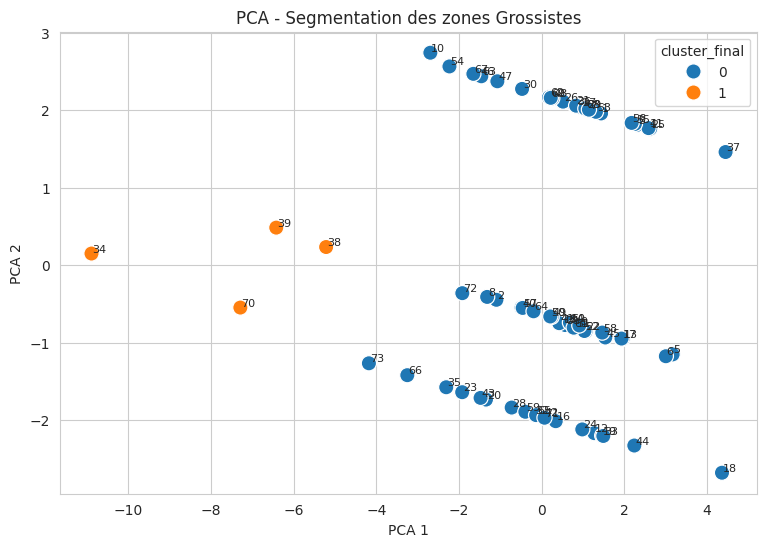

In [174]:
#grossiste
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA sur les données Grossistes
pca_gro = PCA(n_components=2)
gro_pca = pca_gro.fit_transform(X_gro_scaled)

# Ajouter les composantes à la table
gro_zone_ml["pca1"] = gro_pca[:, 0]
gro_zone_ml["pca2"] = gro_pca[:, 1]

# Visualisation
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=gro_zone_ml,
    x="pca1",
    y="pca2",
    hue="cluster_final",
    s=120
)

for _, row in gro_zone_ml.iterrows():
    plt.text(row["pca1"] + 0.02, row["pca2"] + 0.02, str(row["secteur"]), fontsize=8)

plt.title("PCA - Segmentation des zones Grossistes")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

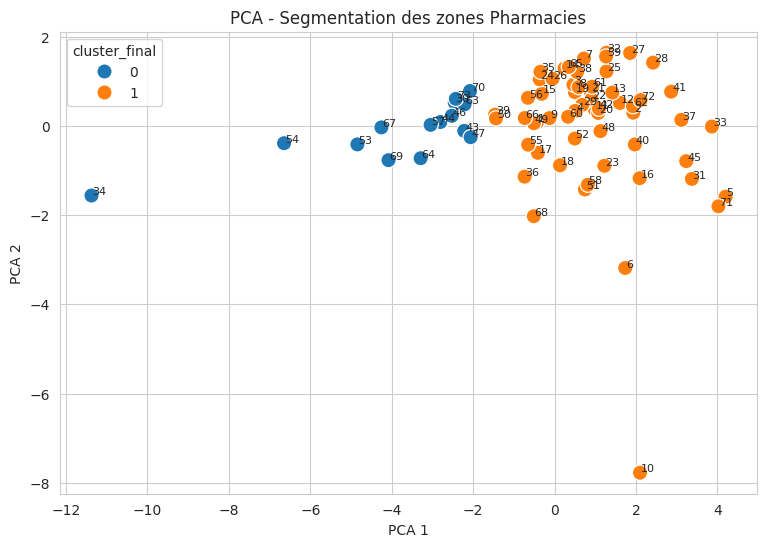

In [175]:
#pharmacie
# PCA sur les données Pharmacies
pca_ph = PCA(n_components=2)
ph_pca = pca_ph.fit_transform(X_ph_scaled)

# Ajouter les composantes à la table
ph_zone_ml["pca1"] = ph_pca[:, 0]
ph_zone_ml["pca2"] = ph_pca[:, 1]

# Visualisation
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=ph_zone_ml,
    x="pca1",
    y="pca2",
    hue="cluster_final",
    s=120
)

for _, row in ph_zone_ml.iterrows():
    plt.text(row["pca1"] + 0.02, row["pca2"] + 0.02, str(row["secteur"]), fontsize=8)

plt.title("PCA - Segmentation des zones Pharmacies")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## XAI - Interprétation de la segmentation des zones

Afin de comprendre les facteurs qui expliquent l’appartenance d’une zone à un cluster, un modèle supervisé explicatif est entraîné à partir des variables de segmentation et des clusters finaux.

In [180]:
# ==============================
# XAI - Zones Grossistes
# ==============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

X_xai_gro = gro_zone_ml[features_zone].fillna(0)
y_xai_gro = gro_zone_ml["cluster_final"]

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_xai_gro,
    y_xai_gro,
    test_size=0.2,
    random_state=42,
    stratify=y_xai_gro
)

xai_model_gro = RandomForestClassifier(n_estimators=200, random_state=42)
xai_model_gro.fit(X_train_g, y_train_g)

y_pred_g = xai_model_gro.predict(X_test_g)

print("Accuracy XAI - Zones Grossistes :", round(accuracy_score(y_test_g, y_pred_g), 4))
print("\nClassification report :\n")
print(classification_report(y_test_g, y_pred_g))

Accuracy XAI - Zones Grossistes : 0.9333

Classification report :

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.50      1.00      0.67         1

    accuracy                           0.93        15
   macro avg       0.75      0.96      0.81        15
weighted avg       0.97      0.93      0.94        15



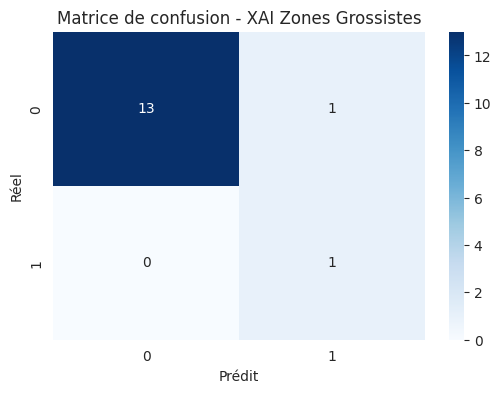

In [181]:
#matrice de confusion GROSSISTE !
cm_gro = confusion_matrix(y_test_g, y_pred_g)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gro, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - XAI Zones Grossistes")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

,feature,importance
7,qte_moyenne_par_ligne,0.191389
0,ca_total,0.185929
8,ca_par_article,0.180851
9,qte_par_article,0.175532
6,ca_moyen_par_ligne,0.137873
1,qte_totale,0.122270
2,nb_articles,0.005289
10,lignes_par_article,0.000469
3,nb_lignes,0.000398
5,nb_bu,0.000000


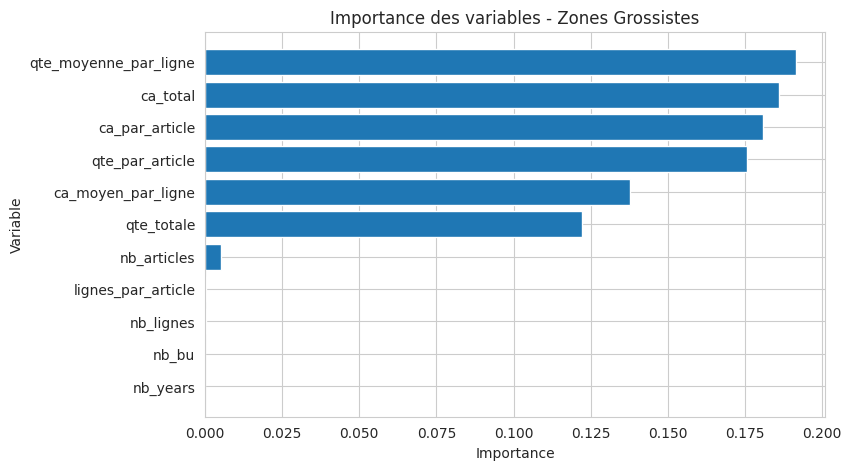

In [182]:
#importance des variables grossistes
importance_gro = pd.DataFrame({
    "feature": features_zone,
    "importance": xai_model_gro.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_gro)

plt.figure(figsize=(8,5))
plt.barh(importance_gro["feature"], importance_gro["importance"])
plt.gca().invert_yaxis()
plt.title("Importance des variables - Zones Grossistes")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

In [183]:
# ==============================
# XAI - Zones Pharmacies
# ==============================

X_xai_ph = ph_zone_ml[features_zone].fillna(0)
y_xai_ph = ph_zone_ml["cluster_final"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_xai_ph,
    y_xai_ph,
    test_size=0.2,
    random_state=42,
    stratify=y_xai_ph
)

xai_model_ph = RandomForestClassifier(n_estimators=200, random_state=42)
xai_model_ph.fit(X_train_p, y_train_p)

y_pred_p = xai_model_ph.predict(X_test_p)

print("Accuracy XAI - Zones Pharmacies :", round(accuracy_score(y_test_p, y_pred_p), 4))
print("\nClassification report :\n")
print(classification_report(y_test_p, y_pred_p))

Accuracy XAI - Zones Pharmacies : 1.0

Classification report :

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        12

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



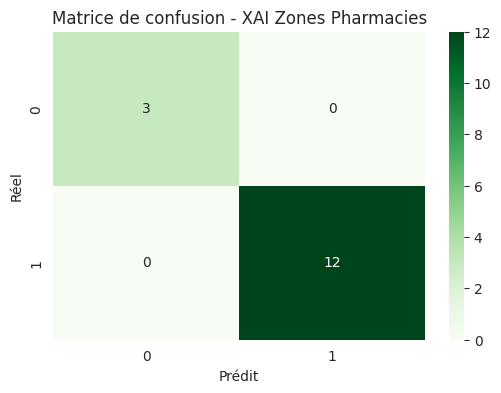

In [184]:
#matrice de confusion pharmacies
cm_ph = confusion_matrix(y_test_p, y_pred_p)

plt.figure(figsize=(6,4))
sns.heatmap(cm_ph, annot=True, fmt="d", cmap="Greens")
plt.title("Matrice de confusion - XAI Zones Pharmacies")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

,feature,importance
9,qte_par_article,0.192010
8,ca_par_article,0.186563
7,qte_moyenne_par_ligne,0.181915
0,ca_total,0.168455
6,ca_moyen_par_ligne,0.131738
1,qte_totale,0.130806
10,lignes_par_article,0.004463
3,nb_lignes,0.004051
2,nb_articles,0.000000
5,nb_bu,0.000000


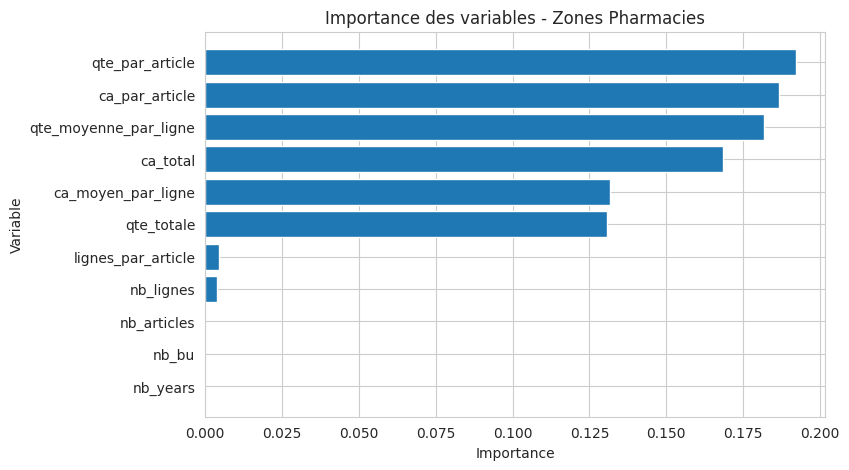

In [185]:
#importance des variables pharmacies
importance_ph = pd.DataFrame({
    "feature": features_zone,
    "importance": xai_model_ph.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_ph)

plt.figure(figsize=(8,5))
plt.barh(importance_ph["feature"], importance_ph["importance"])
plt.gca().invert_yaxis()
plt.title("Importance des variables - Zones Pharmacies")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

20. ANN

In [176]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import numpy as np

def run_ann_classification(zone_ml, features, target_col="cluster_final", test_size=0.2):
    X = zone_ml[features].fillna(0)
    y = zone_ml[target_col]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42, stratify=y
    )

    n_classes = len(np.unique(y))

    model = Sequential([
        Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train, y_train,
        epochs=40,
        batch_size=8,
        validation_split=0.2,
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)

    print("Accuracy ANN :", round(acc, 4))
    print("\nClassification Report :\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Matrice de confusion - ANN")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(history.history["accuracy"], label="train_accuracy")
    plt.plot(history.history["val_accuracy"], label="val_accuracy")
    plt.title("Évolution de l'accuracy - ANN")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    return model, history, acc

cluster_final
0    69
1     4
Name: count, dtype: int64
Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.2609 - loss: 0.9774 - val_accuracy: 0.2500 - val_loss: 0.8615
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5000 - loss: 0.8109 - val_accuracy: 0.5833 - val_loss: 0.7572
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6957 - loss: 0.6420 - val_accuracy: 0.7500 - val_loss: 0.6752
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6957 - loss: 0.7308 - val_accuracy: 0.9167 - val_loss: 0.6038
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6957 - loss: 0.6164 - val_accuracy: 1.0000 - val_loss: 0.5398
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8043 - loss: 0.6134 - val_accuracy: 1.0000 - val_loss: 0.4888
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8913 - loss: 0.5138 - val_accuracy: 1.0000 - val_loss: 0.4480
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8696 -

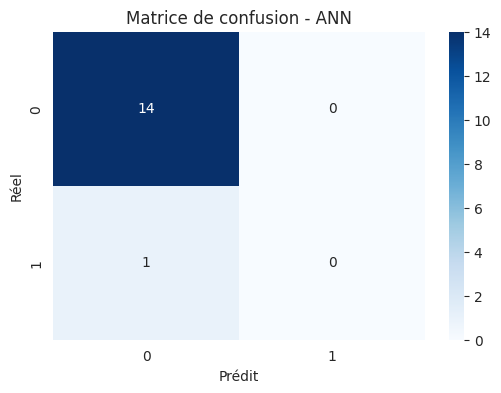

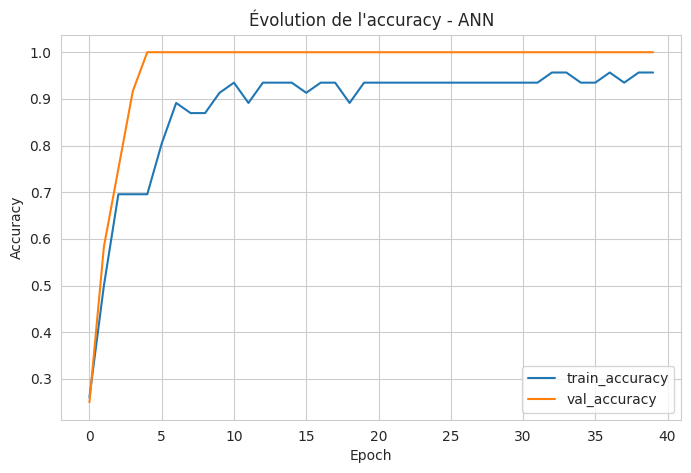

In [177]:
#grossiste
print(gro_zone_ml["cluster_final"].value_counts())


ann_gro_model, ann_gro_history, acc_ann_gro = run_ann_classification(
    gro_zone_ml,
    features_zone,
    target_col="cluster_final",
    test_size=0.2
)

cluster_final
1    58
0    15
Name: count, dtype: int64
Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.3696 - loss: 0.8361 - val_accuracy: 0.2500 - val_loss: 0.8009
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4130 - loss: 0.8069 - val_accuracy: 0.2500 - val_loss: 0.7469
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4783 - loss: 0.7517 - val_accuracy: 0.4167 - val_loss: 0.7001
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5870 - loss: 0.6649 - val_accuracy: 0.5000 - val_loss: 0.6587
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6957 - loss: 0.6462 - val_accuracy: 0.7500 - val_loss: 0.6280
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8696 - loss: 0.5581 - val_accuracy: 0.7500 - val_loss: 0.5983
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8478 - loss: 0.5462 - val_accuracy: 0.7500 - val_loss: 0.5690
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8696 -

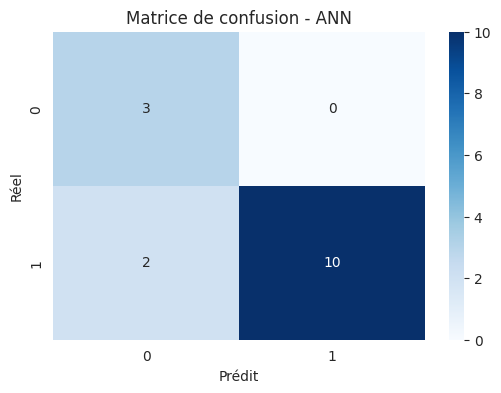

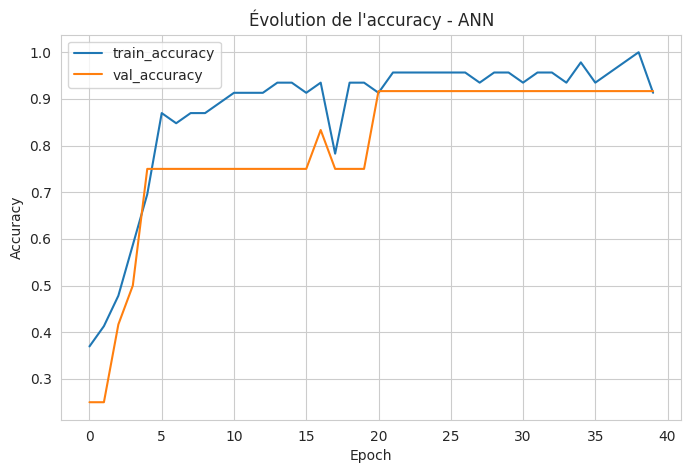

In [178]:
#pharmacie
print(ph_zone_ml["cluster_final"].value_counts())

ann_ph_model, ann_ph_history, acc_ann_ph = run_ann_classification(
    ph_zone_ml,
    features_zone,
    target_col="cluster_final",
    test_size=0.2
)

21. comparaison

In [179]:
final_ann_results = pd.DataFrame({
    "Canal": ["Grossistes", "Pharmacies"],
    "Accuracy_ANN": [round(acc_ann_gro, 4), round(acc_ann_ph, 4)]
})

display(final_ann_results)

,Canal,Accuracy_ANN
0,Grossistes,0.9333
1,Pharmacies,0.8667


sauvegarde du meilleur modèle

In [242]:
from sklearn.cluster import AgglomerativeClustering
import joblib

agg_final_gro = AgglomerativeClustering(n_clusters=2, linkage="ward")
gro_zone_ml["cluster_final"] = agg_final_gro.fit_predict(X_gro_scaled)

joblib.dump(agg_final_gro, f"{base_path}/modele_final_grossistes.pkl")
print("Modèle final Grossistes sauvegardé dans Google Drive.")

Modèle final Grossistes sauvegardé dans Google Drive.


In [243]:
from sklearn.mixture import GaussianMixture

gmm_final_ph = GaussianMixture(n_components=2, random_state=42)
ph_zone_ml["cluster_final"] = gmm_final_ph.fit_predict(X_ph_scaled)

joblib.dump(gmm_final_ph, f"{base_path}/modele_final_pharmacies.pkl")
print("Modèle final Pharmacies sauvegardé dans Google Drive.")

Modèle final Pharmacies sauvegardé dans Google Drive.


# partie git

In [186]:
!git --version

git version 2.34.1


In [187]:
!git clone https://github.com/aymendhieb02/Esprit-PIDEV-4DS3-2026-STRATELLA.git

Cloning into 'Esprit-PIDEV-4DS3-2026-STRATELLA'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 57 (delta 11), reused 34 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 117.38 KiB | 1.22 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [188]:
%cd /content/Esprit-PIDEV-4DS3-2026-STRATELLA

/content/Esprit-PIDEV-4DS3-2026-STRATELLA


In [193]:
!git config --global user.name "molkajerbi"
!git config --global user.email "molka.jerbi@esprit.tn"

In [194]:
!git checkout -b users/molkajerbi/obj3

fatal: A branch named 'users/molkajerbi/obj3' already exists.


In [195]:
!git status

On branch users/molkajerbi/obj3
nothing to commit, working tree clean


In [196]:
!git add .
!git commit -m "obj 3 notebook"
!git push -u origin users/molkajerbi/obj3

On branch users/molkajerbi/obj3
nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [198]:
!find /content/drive -name "*.ipynb"

/content/drive/MyDrive/Colab Notebooks/TP1_SEL_Enoncé__ (2).ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/TP1_SEL_Enoncé__.ipynb
/content/drive/MyDrive/Colab Notebooks/CorrectionTP0-Partie 2 (1).ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/CorrectionTP0-Partie 2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/TP1_SEL_Enoncé__ (1).ipynb
/content/drive/MyDrive/Colab Notebooks/TP2_Interpolation-Approximation_correction.ipynb
/content/drive/MyDrive/Colab Notebooks/TP1 corrigé avec explication du code  Exploration des données .ipynb
/content/drive/MyDrive/Colab Notebooks/TP2 Prétraitement des données Enoncé (1) (1) (1) (1).ipynb
/content/drive/MyDrive/Colab Notebooks/TP2 Prétraitement des données Corrigé (1) (2) (1).ipynb
/content/drive/MyDrive/Colab Notebooks/TP4 Régression Corrigé (1).ipynb
/content/drive/MyDrive/Cola